In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Version: 12.1
GPU Name: NVIDIA RTX A4000


In [2]:
# ============================================================
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
# Target Architecture: E-STDC (STDC Base Network + SwiftFormer EPNet Postprocessing)
# Target Dataset: KITTI (19 semantic classes)[cite: 1]
# Optimization Mode: VRAM-Armored Mixed Precision Training
# ============================================================

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Strict CUDA memory behavior to prevent fragmentation on 16GB VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models

# Schedulers & Data Loading
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR, PolynomialLR
from torch.utils.data import Dataset, DataLoader

# VRAM Optimization Tools (AMP)
from torch.amp import GradScaler, autocast

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm

# --------------------------------------------------
# Cleanup and Warning Control
# --------------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------------------------------
# Reproducibility Setup
# --------------------------------------------------
SEED = 42

def set_seed(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)
print(f"[*] Seed set to {SEED} (deterministic=False for stable/efficient training)")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# --------------------------------------------------
# Matplotlib & Seaborn Styling Setup
# --------------------------------------------------
%matplotlib inline
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# --------------------------------------------------
# Device & Engine Configuration
# --------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Using Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"    GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"    CUDA Toolchain Version: {torch.version.cuda}")
    print(f"    Total Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("    TF32 matrix operations enabled successfully.")
    except Exception as e:
        print(f"    TF32 configuration skipped: {e}")

# --------------------------------------------------
# Strategy Variables for E-STDC
# --------------------------------------------------
PHYSICAL_BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 2  # 4 * 2 = 8 Effective Batch Size

# KITTI shares the exact 19 semantic evaluation classes as Cityscapes[cite: 1]
NUM_CLASSES = 19      

# Native KITTI resolution is 375x1242[cite: 1]. Padded slightly to nearest multiples of 32 for the U-Net architecture.
CROP_HEIGHT = 384
CROP_WIDTH = 1248

USE_AMP = torch.cuda.is_available()
scaler = GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)

print(f"[*] Mixed Precision Training Enabled: {USE_AMP}")
print(f"[*] Targeting Effective Batch Size: {PHYSICAL_BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"[*] Input Resolution Set To: {CROP_HEIGHT}x{CROP_WIDTH}")

# --------------------------------------------------
# CENTRALIZED DIRECTORY & PATH MAPPING
# --------------------------------------------------
KITTI_ROOT = Path("/home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/KITTI/training")
IMG_ROOT = KITTI_ROOT / "image_2"
MASK_ROOT = KITTI_ROOT / "semantic"

FINAL_SAVE_DIR = Path("/home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti") 
QUAL_VIS_DIR = Path("/home/hrusikesh-nishank/Pictures/E-stdc_kitti/training_visuals_E-stdc_kitti")

CHECKPOINT_DIR = FINAL_SAVE_DIR / "progressive_checkpoints_E-stdc_kitti"
PLOTS_DIR = FINAL_SAVE_DIR / "training_plots_E-stdc_kitti"
LOGS_DIR = FINAL_SAVE_DIR / "training_logs_E-stdc_kitti"
METRICS_DIR = FINAL_SAVE_DIR / "training_metrics_E-stdc_kitti"

for d in [CHECKPOINT_DIR, PLOTS_DIR, LOGS_DIR, METRICS_DIR, FINAL_SAVE_DIR, QUAL_VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Model Specifications
# --------------------------------------------------
MODEL_NAME = "E-STDC1" 
MODEL_ALIAS = "E-STDC (STDC1 Base + SwiftFormer EPNet Postprocessing)"

print(f"\n[*] Model Configuration Linked: {MODEL_ALIAS}")
print(f"[*] Pre-trained Model Base: {MODEL_NAME}")
print(f"[*] Global Analytical Results Save Path Linked: {FINAL_SAVE_DIR.resolve()}")

# --------------------------------------------------
# Runtime Performance Containers & Checkpoint Manager
# --------------------------------------------------
HISTORY_FILE = LOGS_DIR / "training_history.csv"

# Tracking dictionary with specific loss breakdowns for base STDC and EPNet
history = {
    "epoch": [],
    "phase": [],
    "train_total_loss": [],
    "train_seg_loss": [],       # STDC main segmentation cross-entropy loss
    "train_detail_loss": [],    # STDC Detail Guidance auxiliary loss (BCE + Dice)
    "train_epnet_loss": [],     # EPNet refined prediction cross-entropy loss
    "train_miou": [],     
    "train_macc": [],     
    "train_aacc": [],     
    "val_total_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],
    "learning_rate": [],
    "epoch_time_sec": [],
    "total_training_time_str": [],
    
    "train_Precision_Macro": [],
    "train_Recall_Macro": [],
    "train_F1_Macro": [],
    "train_Precision_Micro": [],
    "train_Recall_Micro": [],
    "train_F1_Micro": [],
    
    "val_Precision_Macro": [],
    "val_Recall_Macro": [],
    "val_F1_Macro": [],
    "val_Precision_Micro": [],
    "val_Recall_Micro": [],
    "val_F1_Micro": []
}

best_record = {
    "epoch": -1,
    "best_miou": -1.0,
    "best_path": str(CHECKPOINT_DIR / "model_best.pth"),
    "latest_path": str(CHECKPOINT_DIR / "model_latest.pth")
}

def save_checkpoint(epoch, model, optimizer, scaler, scheduler, history_dict, total_time, is_best=False):
    """
    Saves dual checkpoints and directly embeds the full history dictionary.
    Also exports the dictionary to CSV for external plotting immunity against power failure.
    """
    state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'history': history_dict,
        'total_training_time': total_time,
        'best_record': best_record
    }
    
    # 1. Update CSV securely
    pd.DataFrame(history_dict).to_csv(HISTORY_FILE, index=False)
    
    # 2. Always overwrite the latest state
    torch.save(state, best_record['latest_path'])
    
    # 3. Save best state if flagged
    if is_best:
        torch.save(state, best_record['best_path'])
        print(f"\n[+] New Best Model Saved! Val mIoU: {best_record['best_miou']:.2f}% | Epoch: {epoch}")

print("\n[*] Metrics tracking layers constructed. Global paths centralized. Checkpoint Manager ready. Step 1 sequence completed.")

[*] Seed set to 42 (deterministic=False for stable/efficient training)
[*] Using Device: cuda
    GPU Model: NVIDIA RTX A4000
    CUDA Toolchain Version: 12.1
    Total Available GPU Memory: 15.73 GB
    TF32 matrix operations enabled successfully.
[*] Mixed Precision Training Enabled: True
[*] Targeting Effective Batch Size: 8
[*] Input Resolution Set To: 384x1248

[*] Model Configuration Linked: E-STDC (STDC1 Base + SwiftFormer EPNet Postprocessing)
[*] Pre-trained Model Base: E-STDC1
[*] Global Analytical Results Save Path Linked: /home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti

[*] Metrics tracking layers constructed. Global paths centralized. Checkpoint Manager ready. Step 1 sequence completed.


In [3]:
# ============================================================
# STEP 2: HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
# Target Architecture: E-STDC (STDC Base + EPNet Postprocessing)
# Target Dataset: KITTI (19 Classes)[cite: 1]
# Optimization: 120 Epochs, AdamW, LR 5e-4[cite: 1], 384x1248 Crops
# ============================================================

import matplotlib.ticker as mtick 
import torch.nn.functional as F
from pathlib import Path
import numpy as np

print(f"[*] Image root inherited: {IMG_ROOT}")
print(f"[*] Mask root inherited : {MASK_ROOT}")
print(f"[*] Visualizations target: {QUAL_VIS_DIR.resolve()}")
print(f"[*] Final export target: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# CORE TASK SETTINGS (KITTI 19-Class Standard)
# ------------------------------------------------------------
# KITTI maintains the same semantic segmentation annotation format as Cityscapes[cite: 1].
CLASSES = 19
IGNORE_INDEX = 255
USE_LABEL_TRAINIDS = True

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

# Standard Cityscapes/KITTI RGB Color Palette
KITTI_PALETTE = np.array([
    [128, 64, 128],   # Road
    [244, 35, 232],   # Sidewalk
    [70, 70, 70],     # Building
    [102, 102, 156],  # Wall
    [190, 153, 153],  # Fence
    [153, 153, 153],  # Pole
    [250, 170, 30],   # Traffic Light
    [220, 220, 0],    # Traffic Sign
    [107, 142, 35],   # Vegetation
    [152, 251, 152],  # Terrain
    [70, 130, 180],   # Sky
    [220, 20, 60],    # Person
    [255, 0, 0],      # Rider
    [0, 0, 142],      # Car
    [0, 0, 70],       # Truck
    [0, 60, 100],     # Bus
    [0, 80, 100],     # Train
    [0, 0, 230],      # Motorcycle
    [119, 11, 32]     # Bicycle
], dtype=np.uint8)

# ------------------------------------------------------------
# IMAGE GEOMETRY & CROP SIZE (E-STDC KITTI Standard)
# ------------------------------------------------------------
# KITTI provides images at a lower resolution of 375x1242 pixels[cite: 1].
# We pad to 384x1248 to ensure divisibility by 32 for the U-Net/SwiftFormer structures.
IMG_H = 384
IMG_W = 1248
VAL_IMG_H = 384  
VAL_IMG_W = 1248  

# ------------------------------------------------------------
# TRAINING EPOCHS
# ------------------------------------------------------------
EPOCHS = 120
USE_EARLY_STOPPING = False  

# ------------------------------------------------------------
# OPTIMIZATION SCHEDULE (AdamW as specified in EPNet paper)
# ------------------------------------------------------------
# Employed an AdamW optimizer with an initial learning rate of 5x10-4 and a decay rate of 0.01 for optimization[cite: 1].
OPTIMIZER_TYPE = "AdamW"
BASE_LR = 5e-4            
WEIGHT_DECAY = 0.01       

print("\n--- E-STDC Optimization Schedule ---")
print(f"Target Total Epochs     : {EPOCHS}")
print(f"Optimizer Type          : {OPTIMIZER_TYPE}")
print(f"Base Learning Rate      : {BASE_LR}")
print(f"Weight Decay            : {WEIGHT_DECAY}")
print(f"Crop Size               : {IMG_H}x{IMG_W}")

# ------------------------------------------------------------
# VALIDATION / INFERENCE SETTINGS
# ------------------------------------------------------------
USE_SLIDING_WINDOW_VAL = False
VAL_WINDOW_SIZE = (384, 1248)
VAL_WINDOW_STRIDE = (384, 1248)   
USE_FLIP_TTA = True              

# ------------------------------------------------------------
# 34 -> 19 LABEL MAPPING & ENCODING (KITTI/Cityscapes Specific)
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    uniq = np.unique(mask)
    if uniq.max() <= 255 and np.all(np.isin(uniq, list(range(CLASSES)) + [IGNORE_INDEX])):
        return mask.astype(np.uint8)
    encoded = LABEL_LUT[mask.clip(0, 255)]
    return encoded.astype(np.uint8)

def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    valid_mask = (segmentation_map >= 0) & (segmentation_map < CLASSES)
    for label, color in enumerate(KITTI_PALETTE):
        rgb[segmentation_map == label] = color
    rgb[~valid_mask] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb

# ------------------------------------------------------------
# PUBLICATION-READY EVALUATION CURVES (Strictly % Formatted)
# ------------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_training_curves(history_dict, save_path=FINAL_SAVE_DIR):
    keys_to_extract = ['epoch', 'train_total_loss', 'val_total_loss', 'train_miou', 'val_miou', 'train_F1_Macro', 'val_F1_Macro']
    safe_dict = {}
    
    target_len = len(history_dict.get('epoch', []))
    if target_len == 0: return

    for k in keys_to_extract:
        if k in history_dict:
            col = history_dict[k]
            if len(col) > target_len:
                safe_dict[k] = col[:target_len]
            elif len(col) < target_len:
                safe_dict[k] = col + [np.nan] * (target_len - len(col))
            else:
                safe_dict[k] = col
        else:
            safe_dict[k] = [np.nan] * target_len

    df = pd.DataFrame(safe_dict)

    interval_df = df[(df['epoch'] % 5 == 0) | (df['epoch'] == df['epoch'].max())].copy()
    
    if interval_df.empty: return
    epochs_filtered = interval_df['epoch'].values

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    axes[0].plot(epochs_filtered, interval_df["train_total_loss"], marker='o', label='Train Loss', color='blue', linewidth=2)
    if not interval_df["val_total_loss"].isna().all():
        axes[0].plot(epochs_filtered, interval_df["val_total_loss"], marker='s', label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Loss Progress', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=12)

    axes[1].plot(epochs_filtered, interval_df["train_miou"], marker='o', label='Train mIoU', color='green', linewidth=2)
    if not interval_df["val_miou"].isna().all():
        axes[1].plot(epochs_filtered, interval_df["val_miou"], marker='s', label='Validation mIoU', color='orange', linewidth=2)
    axes[1].set_title('mIoU Progress', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('mIoU', fontsize=12)
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
    axes[1].legend(fontsize=12)

    axes[2].plot(epochs_filtered, interval_df["train_F1_Macro"], marker='o', label='Train F1 (Macro)', color='purple', linewidth=2)
    if not interval_df["val_F1_Macro"].isna().all():
        axes[2].plot(epochs_filtered, interval_df["val_F1_Macro"], marker='s', label='Validation F1 (Macro)', color='magenta', linewidth=2)
    axes[2].set_title('F1-Score Progress', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('F1 Score', fontsize=12)
    axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
    axes[2].legend(fontsize=12)

    plt.tight_layout()
    
    combined_graph_path = save_path / "presentation_metrics_progress_ESTDC_kitti.png"
    plt.savefig(combined_graph_path, dpi=600, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# QUALITATIVE VISUALIZATION (E-STDC Adapted)
# ------------------------------------------------------------
import torch

def visualize_results(loader, model, epoch, save_path=QUAL_VIS_DIR, max_images=3):
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)
    model.eval()

    batch = next(iter(loader))
    images, targets = batch[0], batch[1]
    images = images.to(DEVICE)
    _, _, current_h, current_w = images.shape
    
    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=(torch.cuda.is_available() and images.is_cuda)):
            outputs = model(images)
            # E-STDC output mapping: grab the final refined mask
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            logits_up = F.interpolate(logits, size=(current_h, current_w), mode="bilinear", align_corners=False)
            preds = torch.argmax(logits_up, dim=1).cpu().numpy()

    images_np = images.detach().cpu().numpy()
    targets_np = targets.cpu().numpy()

    n = min(max_images, len(images_np))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = np.transpose(images_np[i], (1, 2, 0))
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_segmap(targets_np[i]))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_segmap(preds[i]))
        axes[i, 2].set_title(f"E-STDC Prediction (Epoch {epoch})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    out_file = save_path / f"epoch_{epoch:03d}_comparison.png"
    plt.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.close(fig)

def save_visuals_every_10_epochs(epoch, loader, model, save_path=QUAL_VIS_DIR, max_images=3):
    if epoch > 0 and epoch % 10 == 0:
        visualize_results(loader, model, epoch, save_path, max_images)

print("[*] Step 2 strictly configured for E-STDC Architecture Replication on KITTI.")

[*] Image root inherited: /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/KITTI/training/image_2
[*] Mask root inherited : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/KITTI/training/semantic
[*] Visualizations target: /home/hrusikesh-nishank/Pictures/E-stdc_kitti/training_visuals_E-stdc_kitti
[*] Final export target: /home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti

--- E-STDC Optimization Schedule ---
Target Total Epochs     : 120
Optimizer Type          : AdamW
Base Learning Rate      : 0.0005
Weight Decay            : 0.01
Crop Size               : 384x1248
[*] Step 2 strictly configured for E-STDC Architecture Replication on KITTI.


In [4]:
# ============================================================
# STEP 3: DATASET AND DATALOADERS (E-STDC Adapted for KITTI)
# Target Architecture: E-STDC (STDC Base + EPNet Postprocessing)
# Target Dataset: KITTI
# Optimized for: 384x1248 Crops, Paper-Exact Augmentations
# ============================================================

import inspect
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import random

# Prevent OpenCV from locking/choking threads during PyTorch multiprocessing
cv2.setNumThreads(0)

# Note: All major libraries (torch, cv2, albumentations, numpy), paths, 
# and mapping variables are securely inherited from Steps 1 & 2.

# ------------------------------------------------------------
# DATASET DISCOVERY FOR KITTI
# ------------------------------------------------------------
def get_kitti_pairs(split):
    """
    Finds KITTI image/mask pairs. If the user has pre-split the dataset 
    into 'train' and 'val' subdirectories, it uses them. Otherwise, it safely 
    performs an 80/20 deterministic split on the flat 200-image training directory.
    """
    img_split_dir = KITTI_ROOT / split / "image_2"
    mask_split_dir = KITTI_ROOT / split / "semantic"
    
    # Check if pre-split folders exist
    if img_split_dir.exists() and mask_split_dir.exists():
        all_imgs = sorted(list(img_split_dir.rglob("*.png")))
        mask_dir_to_use = mask_split_dir
    else:
        # Fallback to flat directory and split deterministically
        all_imgs = sorted(list(IMG_ROOT.rglob("*.png")))
        mask_dir_to_use = MASK_ROOT
        
        # Deterministic 80/20 Split
        random.seed(SEED)
        all_imgs_shuffled = all_imgs.copy()
        random.shuffle(all_imgs_shuffled)
        
        split_idx = int(len(all_imgs_shuffled) * 0.8)
        if split == "train":
            all_imgs = all_imgs_shuffled[:split_idx]
        else:
            all_imgs = all_imgs_shuffled[split_idx:]
    
    valid_imgs = []
    valid_masks = []
    
    for img_path in all_imgs:
        mask_path = mask_dir_to_use / img_path.name
        
        if mask_path.exists():
            valid_imgs.append(img_path)
            valid_masks.append(mask_path)
            
    return valid_imgs, valid_masks

train_img_paths, train_mask_paths = get_kitti_pairs("train")
val_img_paths, val_mask_paths = get_kitti_pairs("val")

if len(train_img_paths) == 0 or len(val_img_paths) == 0:
    raise FileNotFoundError("Could not find valid KITTI image/mask pairs. Please check paths.")

print(f"\n--- KITTI Dataset Split ---")
print(f"[*] Training image/mask pairs   : {len(train_img_paths)}")
print(f"[*] Validation image/mask pairs : {len(val_img_paths)}")

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
class KITTIDataset(Dataset):
    def __init__(self, image_paths, mask_paths, split="train", transform=None):
        self.transform = transform
        self.split = split
        self.images = image_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = str(self.images[idx])
        mask_path = str(self.masks[idx])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask_raw is None:
            raise ValueError(f"Failed to read mask: {mask_path}")
            
        # Inherited directly from Step 2 (34-to-19 mapping)
        mask = encode_mask(mask_raw)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        if not torch.is_tensor(image):
            image = torch.as_tensor(image).permute(2, 0, 1).float()
        
        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask, dtype=torch.long)
        else:
            mask = mask.long()

        return image, mask

# ------------------------------------------------------------
# AUGMENTATION HELPERS & TRANSFORMS
# ------------------------------------------------------------
def pad_if_needed_tf(min_h, min_w, ignore_index=255):
    sig = inspect.signature(A.PadIfNeeded)
    kwargs = dict(min_height=min_h, min_width=min_w, border_mode=cv2.BORDER_CONSTANT, p=1.0)
    if "fill" in sig.parameters:
        kwargs.update(fill=0, fill_mask=ignore_index)
    else:
        kwargs.update(value=0, mask_value=ignore_index)
    return A.PadIfNeeded(**kwargs)

# Data augmentation contains color jittering, random horizontal flip, random crop and random resize.
# For KITTI's unique 375x1242 aspect ratio, scale limits are kept at [0.5, 2.0] to prevent extreme padding.
train_transform = A.Compose([
    A.RandomScale(scale_limit=(-0.5, 1.0), interpolation=cv2.INTER_LINEAR, p=1.0), 
    pad_if_needed_tf(IMG_H, IMG_W, IGNORE_INDEX),
    A.RandomCrop(height=IMG_H, width=IMG_W, p=1.0),
    A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1, p=0.5), 
    A.HorizontalFlip(p=0.5), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# Validation transform runs at native resolution
val_transform = A.Compose([
    pad_if_needed_tf(VAL_IMG_H, VAL_IMG_W, IGNORE_INDEX),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# ------------------------------------------------------------
# COLLATE FUNCTION 
# ------------------------------------------------------------
def dense_collate_fn(batch):
    images = torch.stack([item[0] for item in batch], dim=0)
    masks = torch.stack([item[1] for item in batch], dim=0)
    return images, masks

# ------------------------------------------------------------
# INITIALIZATION
# ------------------------------------------------------------

train_dataset = KITTIDataset(
    image_paths=train_img_paths, mask_paths=train_mask_paths, split="train",
    transform=train_transform
)

val_dataset = KITTIDataset(
    image_paths=val_img_paths, mask_paths=val_mask_paths, split="val",
    transform=val_transform
)

# CRASH FIX: Limit workers slightly and enforce PERSISTENT_WORKERS = False 
# to stop Jupyter IPC socket file descriptor limits from crashing the loop.
NUM_WORKERS = min(2, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = False

print(f"\n--- DataLoader Hardware Configuration ---")
print(f"[*] Num workers     : {NUM_WORKERS}")
print(f"[*] Pin memory      : {PIN_MEMORY}")
print(f"[*] Persistent wkrs : {PERSISTENT_WORKERS} (Disabled for OS stability)")

train_loader = DataLoader(
    train_dataset, batch_size=PHYSICAL_BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    collate_fn=dense_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
    collate_fn=dense_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
train_batch = next(iter(train_loader))
train_images, train_masks = train_batch

print("\n--- Train Batch Sanity Check ---")
print(f"[*] Images shape    : {train_images.shape} (Targeting {IMG_H}x{IMG_W})")
print(f"[*] Masks shape     : {train_masks.shape}")

val_batch = next(iter(val_loader))
val_images, val_masks = val_batch

assert train_images.shape[-2:] == (IMG_H, IMG_W), f"Expected train crop {IMG_H}x{IMG_W}, got {train_images.shape[-2:]}"

print(f"[*] Val images shape: {val_images.shape} (Native KITTI Resolution padded to U-Net compatibility)")
print("\n[*] Step 3 configured successfully and ready to feed the E-STDC model.")


--- KITTI Dataset Split ---
[*] Training image/mask pairs   : 160
[*] Validation image/mask pairs : 40

--- DataLoader Hardware Configuration ---
[*] Num workers     : 2
[*] Pin memory      : True
[*] Persistent wkrs : False (Disabled for OS stability)

--- Train Batch Sanity Check ---
[*] Images shape    : torch.Size([4, 3, 384, 1248]) (Targeting 384x1248)
[*] Masks shape     : torch.Size([4, 384, 1248])
[*] Val images shape: torch.Size([1, 3, 384, 1248]) (Native KITTI Resolution padded to U-Net compatibility)

[*] Step 3 configured successfully and ready to feed the E-STDC model.


In [5]:
# ============================================================
# STEP 4: MODEL, OPTIMIZER, LOSS, MULTI-RATE SCHEDULER (KITTI)
# Target Architecture: E-STDC (STDC1 Base + EPNet Postprocessing)
# Optimized for: Kaiming Initialization, LR Warmup, EPNet Fix
# ============================================================

import os
import math
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR

if "train_loader" not in globals():
    raise NameError("train_loader is not defined. Please run Step 3 first.")

DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
CLASSES = globals().get("CLASSES", 19)
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)

BASE_LR = globals().get("BASE_LR", 5e-4)
WEIGHT_DECAY = globals().get("WEIGHT_DECAY", 0.01)
EPOCHS = globals().get("EPOCHS", 120)

# ------------------------------------------------------------
# WEIGHT INITIALIZATION (CRITICAL FOR TRAINING FROM SCRATCH)
# ------------------------------------------------------------
def kaiming_weight_init(module):
    """Applies Kaiming Normal initialization to prevent vanishing gradients."""
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0, 0.01)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

# ============================================================
# PART 1: STDC NETWORK (BASE)
# ============================================================
class ConvX(nn.Module):
    def __init__(self, in_planes, out_planes, kernel=3, stride=1):
        super(ConvX, self).__init__()
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size=kernel, stride=stride, padding=kernel//2, bias=False)
        self.bn = nn.BatchNorm2d(out_planes)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class STDCModule(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super(STDCModule, self).__init__()
        self.stride = stride
        c1 = out_channels // 2
        c2 = c1 // 2
        c3 = c2 // 2
        c4 = c3  

        self.block1 = ConvX(in_channels, c1, kernel=1, stride=1)
        self.block2 = ConvX(c1, c2, kernel=3, stride=stride)
        self.block3 = ConvX(c2, c3, kernel=3, stride=1)
        self.block4 = ConvX(c3, c4, kernel=3, stride=1)

        if stride == 2:
            self.avg_pool = nn.AvgPool2d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        x1 = self.block1(x)
        x2 = self.block2(x1)
        x3 = self.block3(x2)
        x4 = self.block4(x3)

        if self.stride == 2:
            x1 = self.avg_pool(x1)

        return torch.cat([x1, x2, x3, x4], dim=1)

class AttentionRefineModule(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(AttentionRefineModule, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        feat = self.bn(self.conv(x))
        attn = self.attention(feat)
        return feat * attn

class FeatureFusionModule(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(FeatureFusionModule, self).__init__()
        self.convblk = ConvX(in_channels, out_channels, kernel=1)
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels // 4, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels, kernel_size=1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, fsp, fcp):
        fcat = torch.cat([fsp, fcp], dim=1)
        feat = self.convblk(fcat)
        attn = self.attention(feat)
        return feat + feat * attn

class STDCNet(nn.Module):
    def __init__(self, num_classes=19):
        super(STDCNet, self).__init__()
        self.stage1 = ConvX(3, 32, kernel=3, stride=2)   
        self.stage2 = ConvX(32, 64, kernel=3, stride=2)  
        self.stage3 = STDCModule(64, 256, stride=2)      
        self.stage4 = STDCModule(256, 512, stride=2)     
        self.stage5 = STDCModule(512, 1024, stride=2)    

        self.arm4 = AttentionRefineModule(512, 128)
        self.arm5 = AttentionRefineModule(1024, 128)
        self.ffm = FeatureFusionModule(256 + 128, 256)

        self.seg_head = nn.Sequential(
            ConvX(256, 256, kernel=3),
            nn.Conv2d(256, num_classes, kernel_size=1)
        )
        self.detail_head = nn.Sequential(
            ConvX(256, 64, kernel=3),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        h, w = x.shape[2:]
        feat2 = self.stage1(x)
        feat4 = self.stage2(feat2)
        feat8 = self.stage3(feat4)
        feat16 = self.stage4(feat8)
        feat32 = self.stage5(feat16)

        feat32_arm = self.arm5(feat32)
        feat32_up = F.interpolate(feat32_arm, size=feat16.shape[2:], mode='nearest')
        
        feat16_arm = self.arm4(feat16)
        feat16_sum = feat16_arm + feat32_up
        feat16_up = F.interpolate(feat16_sum, size=feat8.shape[2:], mode='nearest')

        feat_fuse = self.ffm(feat8, feat16_up)
        
        seg_logits = self.seg_head(feat_fuse)
        detail_logits = self.detail_head(feat8)

        seg_logits = F.interpolate(seg_logits, size=(h, w), mode='bilinear', align_corners=False)
        detail_logits = F.interpolate(detail_logits, size=(h, w), mode='bilinear', align_corners=False)

        if self.training:
            return seg_logits, detail_logits
        return seg_logits

# ============================================================
# PART 2: EPNet POSTPROCESSING NETWORK
# ============================================================
class SwiftFormerBlockProxy(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim, bias=False)
        self.norm = nn.BatchNorm2d(dim)
        self.pwconv1 = nn.Conv2d(dim, dim * 4, kernel_size=1, bias=False)
        self.act = nn.GELU()
        self.pwconv2 = nn.Conv2d(dim * 4, dim, kernel_size=1, bias=False)

    def forward(self, x):
        res = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        return x + res

class EPNet(nn.Module):
    def __init__(self, num_classes=19):
        super(EPNet, self).__init__()
        in_dim = num_classes + 3 
        
        self.patch_embed = nn.Sequential(
            nn.Conv2d(in_dim, 48, kernel_size=4, stride=4, padding=0, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        self.enc1 = SwiftFormerBlockProxy(48)
        self.down1 = nn.Conv2d(48, 56, kernel_size=2, stride=2)
        self.enc2 = SwiftFormerBlockProxy(56) 
        self.down2 = nn.Conv2d(56, 112, kernel_size=2, stride=2)
        self.enc3 = SwiftFormerBlockProxy(112)
        self.down3 = nn.Conv2d(112, 220, kernel_size=2, stride=2)
        self.enc4 = SwiftFormerBlockProxy(220)

        self.up4 = nn.ConvTranspose2d(220, 112, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn4 = nn.BatchNorm2d(112)
        self.up3 = nn.ConvTranspose2d(112, 56, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn3 = nn.BatchNorm2d(56)
        self.up2 = nn.ConvTranspose2d(56, 48, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn2 = nn.BatchNorm2d(48)
        self.up1 = nn.ConvTranspose2d(48, 48, kernel_size=5, stride=4, padding=2, output_padding=3)
        self.bn1 = nn.BatchNorm2d(48)

        self.affinity_head = nn.Sequential(
            nn.Conv2d(48, 24, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(24, 12, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(12, 8, kernel_size=3, padding=1)
        )

    def forward(self, rgb, logits):
        # BUG FIX: Removed rgb / 255.0. Albumentation standardizes it directly to [-2.5, 2.5]
        probs = F.softmax(logits, dim=1) 
        x = torch.cat([probs, rgb], dim=1) 
        
        e1 = self.enc1(self.patch_embed(x))
        e2 = self.enc2(self.down1(e1))
        e3 = self.enc3(self.down2(e2))
        e4 = self.enc4(self.down3(e3))

        d4_up = self.up4(e4)
        if d4_up.shape[2:] != e3.shape[2:]: d4_up = F.interpolate(d4_up, size=e3.shape[2:], mode='bilinear')
        d4 = F.relu(self.bn4(d4_up)) + e3

        d3_up = self.up3(d4)
        if d3_up.shape[2:] != e2.shape[2:]: d3_up = F.interpolate(d3_up, size=e2.shape[2:], mode='bilinear')
        d3 = F.relu(self.bn3(d3_up)) + e2

        d2_up = self.up2(d3)
        if d2_up.shape[2:] != e1.shape[2:]: d2_up = F.interpolate(d2_up, size=e1.shape[2:], mode='bilinear')
        d2 = F.relu(self.bn2(d2_up)) + e1

        d1_up = self.up1(d2)
        if d1_up.shape[2:] != x.shape[2:]: d1_up = F.interpolate(d1_up, size=x.shape[2:], mode='bilinear')
        d1 = F.relu(self.bn1(d1_up))

        return self.affinity_head(d1)

# ============================================================
# PART 3: SPATIAL PROPAGATION & E-STDC WRAPPER
# ============================================================
def spatial_propagation_suip(initial_logits, affinity, iters=7):
    B, C, H, W = initial_logits.shape
    affinity_abs = torch.abs(affinity)
    affinity_sum = torch.sum(affinity_abs, dim=1, keepdim=True) + 1e-8
    k_neighbors = affinity / affinity_sum 
    k_center = 1.0 - torch.sum(k_neighbors, dim=1, keepdim=True) 

    active_mask = torch.argmax(initial_logits, dim=1) 
    class_idx = torch.arange(C, device=initial_logits.device).view(1, C, 1, 1)
    presence_mask = (active_mask.unsqueeze(1) == class_idx).any(dim=-1).any(dim=-1).view(B, C, 1, 1).float() 

    M_0, M_t = initial_logits.clone(), initial_logits.clone()
    shifts_offsets = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

    for t in range(iters):
        base_contrib = k_center * M_0
        neighbor_contrib = 0.0
        padded_M = F.pad(M_t, (1, 1, 1, 1), mode='replicate')
        
        for idx, (dx, dy) in enumerate(shifts_offsets):
            shifted = padded_M[:, :, 1+dx : 1+dx+H, 1+dy : 1+dy+W]
            neighbor_contrib = neighbor_contrib + (k_neighbors[:, idx:idx+1, :, :] * shifted)
        
        M_t = torch.where(presence_mask.bool(), base_contrib + neighbor_contrib, M_t)

    return M_t

class ESTDC(nn.Module):
    def __init__(self, num_classes=19, propagation_iters=7):
        super(ESTDC, self).__init__()
        self.stdc = STDCNet(num_classes)
        self.epnet = EPNet(num_classes)
        self.propagation_iters = propagation_iters
        
        # APPLY KAIMING INITIALIZATION
        kaiming_weight_init(self.stdc)
        kaiming_weight_init(self.epnet)

    def forward(self, rgb):
        if self.training:
            seg_logits, detail_logits = self.stdc(rgb)
            affinity = self.epnet(rgb, seg_logits.detach()) 
            refined_logits = spatial_propagation_suip(seg_logits.detach(), affinity, iters=self.propagation_iters)
            return refined_logits, seg_logits, detail_logits
        else:
            seg_logits = self.stdc(rgb)
            affinity = self.epnet(rgb, seg_logits)
            return spatial_propagation_suip(seg_logits, affinity, iters=17) 

# ------------------------------------------------------------
# LOAD MODEL & OPTIMIZER 
# ------------------------------------------------------------
model = ESTDC(num_classes=CLASSES, propagation_iters=7).to(DEVICE)
print(f"[*] Loaded E-STDC Architecture with Kaiming Init for {CLASSES} classes.")

optimizer = optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)

# ------------------------------------------------------------
# LOSS FUNCTIONS 
# ------------------------------------------------------------
class OHEMCrossEntropyLoss(nn.Module):
    def __init__(self, ignore_index=255, thresh=0.7, min_kept=100000):
        super(OHEMCrossEntropyLoss, self).__init__()
        self.ignore_index = ignore_index
        self.thresh = thresh
        self.min_kept = min_kept
        self.criterion = nn.CrossEntropyLoss(ignore_index=ignore_index, reduction='none')

    def forward(self, pred, target):
        loss = self.criterion(pred, target).view(-1)
        valid_mask = target.view(-1) != self.ignore_index
        valid_loss = loss[valid_mask]
        if len(valid_loss) == 0: return loss.sum() * 0.0
            
        sorted_loss, _ = torch.sort(valid_loss, descending=True)
        if len(sorted_loss) > self.min_kept:
            threshold = max(sorted_loss[self.min_kept].item(), self.thresh)
            valid_loss = valid_loss[valid_loss > threshold]
        return valid_loss.mean()

class DetailLoss(nn.Module):
    def __init__(self):
        super(DetailLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        pred = pred.squeeze(1)
        bce_loss = self.bce(pred, target) 
        pred_sigmoid = torch.sigmoid(pred)
        intersection = (pred_sigmoid * target).sum()
        dice_loss = 1 - (2. * intersection + 1) / (pred_sigmoid.pow(2).sum() + target.pow(2).sum() + 1) 
        return bce_loss + dice_loss

def generate_detail_gt(masks, ignore_index=255):
    B, H, W = masks.shape
    laplacian_kernel = torch.tensor([[-1., -1., -1.], [-1., 8., -1.], [-1., -1., -1.]], device=masks.device) 
    laplacian_kernel = laplacian_kernel.view(1, 1, 3, 3).repeat(CLASSES, 1, 1, 1)
    
    valid_mask = (masks != ignore_index).float()
    masks_onehot = F.one_hot(torch.clamp(masks, 0, CLASSES-1), num_classes=CLASSES).permute(0, 3, 1, 2).float()
    boundary = torch.clamp(F.conv2d(masks_onehot, laplacian_kernel, padding=1, groups=CLASSES), 0, 1)
    detail_gt, _ = torch.max(boundary, dim=1)
    return detail_gt * valid_mask

seg_criterion = OHEMCrossEntropyLoss(ignore_index=IGNORE_INDEX)
detail_criterion = DetailLoss()
epnet_criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

def estdc_loss(outputs, targets, current_epoch, warmup_epochs=50):
    if isinstance(outputs, tuple):
        refined_logits, seg_logits, detail_logits = outputs
        loss_seg = seg_criterion(seg_logits, targets)
        loss_detail = detail_criterion(detail_logits, generate_detail_gt(targets))
        loss_epnet = epnet_criterion(refined_logits, targets)
        
        if current_epoch <= warmup_epochs:
            return loss_seg + loss_detail, loss_seg, loss_detail, torch.tensor(0.0, device=targets.device)
        else:
            return loss_seg + loss_detail + loss_epnet, loss_seg, loss_detail, loss_epnet
    return epnet_criterion(outputs, targets), None, None, None

# ------------------------------------------------------------
# SCHEDULER: 10-EPOCH WARMUP + POLYNOMIAL DECAY
# ------------------------------------------------------------
def get_warmup_poly_scheduler(optimizer, total_steps, warmup_steps, power=0.9):
    def lr_lambda(current_step: int):
        if current_step < warmup_steps:
            # Linear Warmup from 1% to 100% of BASE_LR
            return max(0.01, float(current_step) / float(max(1, warmup_steps)))
        else:
            # Polynomial Decay
            progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return max(0.0, (1.0 - progress) ** power)
    return LambdaLR(optimizer, lr_lambda)

# ------------------------------------------------------------
# SYSTEM INITIALIZATION
# ------------------------------------------------------------
steps_per_epoch = math.ceil(len(train_loader) / globals().get("GRAD_ACCUM_STEPS", 2))
total_update_steps = steps_per_epoch * EPOCHS
warmup_update_steps = steps_per_epoch * 10  # 10 Epochs of exact Linear Warmup

scheduler = get_warmup_poly_scheduler(optimizer, total_update_steps, warmup_update_steps, power=0.9)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Unified E-STDC Architecture Initialized ---")
print(f"[*] Total parameters     : {total_params:,} (STDC + EPNet)")
print(f"[*] Trainable parameters : {trainable_params:,}")
print(f"[*] Optimizer            : AdamW (Base LR={BASE_LR} with 10-Epoch Warmup)")

[*] Loaded E-STDC Architecture with Kaiming Init for 19 classes.

--- Unified E-STDC Architecture Initialized ---
[*] Total parameters     : 6,765,464 (STDC + EPNet)
[*] Trainable parameters : 6,765,464
[*] Optimizer            : AdamW (Base LR=0.0005 with 10-Epoch Warmup)


In [6]:
# ============================================================
# STEP 5: TRAINING LOOP (E-STDC Architecture) - KITTI READY
# Target Architecture: E-STDC (STDC Base + EPNet Postprocessing)
# Target Dataset: KITTI
# Optimized for: Multi-Loss Tracking, Two-Stage Warmup, AdamW
# ============================================================

import os
import gc
import time
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm

# ------------------------------------------------------------
# KITTI CONFIGURATION & GLOBALS
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
USE_AMP = globals().get("USE_AMP", torch.cuda.is_available())

GRAD_CLIP_NORM = globals().get("GRAD_CLIP_NORM", 1.0) 
MIN_DELTA_MIOU = 0.001
EPOCHS = globals().get("EPOCHS", 120) 
CLASSES = globals().get("CLASSES", 19)          
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255) 
WARMUP_EPOCHS = globals().get("WARMUP_EPOCHS", 50)

# Output Paths updated for KITTI
FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("/home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti"))
QUAL_VIS_DIR = globals().get("QUAL_VIS_DIR", Path("/home/hrusikesh-nishank/Pictures/E-stdc_kitti/training_visuals_E-stdc_kitti"))
latest_ckpt_path = FINAL_SAVE_DIR / "latest_model_estdc_kitti.pt"
best_ckpt_path = FINAL_SAVE_DIR / "best_model_estdc_kitti.pt"

# ------------------------------------------------------------
# INFERENCE PASS (SAFE TUPLE UNPACKING)
# ------------------------------------------------------------
def estdc_val_inference(model, image, current_epoch, warmup_epochs=50, use_flip_tta=False):
    B, C, H, W = image.shape
    model.eval() 
    
    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=USE_AMP):
            if current_epoch <= warmup_epochs:
                logits = model.stdc(image)
            else:
                logits = model(image)
            
            # Unpack if model returns tuple/list
            if isinstance(logits, (tuple, list)):
                logits = logits[0]
            
            if use_flip_tta:
                flipped_img = torch.flip(image, dims=[3])
                if current_epoch <= warmup_epochs:
                    flip_logits = model.stdc(flipped_img)
                else:
                    flip_logits = model(flipped_img)
                
                if isinstance(flip_logits, (tuple, list)):
                    flip_logits = flip_logits[0]
                    
                logits = (logits + torch.flip(flip_logits, dims=[3])) / 2.0
            
            logits_up = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)
            
    return logits_up.float()

# ------------------------------------------------------------
# METRICS & CONFUSION MATRIX
# ------------------------------------------------------------
def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    
    precision_class = tp / np.maximum(tp + fp, 1)
    recall_class = tp / np.maximum(tp + fn, 1)
    iou_class = tp / np.maximum(tp + fp + fn, 1)
    f1_class = 2 * (precision_class * recall_class) / np.maximum(precision_class + recall_class, 1e-8)

    # Only average over classes present in Ground Truth
    present_classes = (tp + fn) > 0
    if not np.any(present_classes):
        present_classes = np.ones(len(tp), dtype=bool)

    macro_precision = np.nanmean(precision_class[present_classes])
    macro_recall = np.nanmean(recall_class[present_classes])
    macro_f1 = np.nanmean(f1_class[present_classes])
    macro_miou = np.nanmean(iou_class[present_classes])

    total_tp, total_fp, total_fn = tp.sum(), fp.sum(), fn.sum()
    micro_precision = total_tp / max(total_tp + total_fp, 1)
    micro_recall = total_tp / max(total_tp + total_fn, 1)
    micro_f1 = 2 * (micro_precision * micro_recall) / max(micro_precision + micro_recall, 1e-8)
    micro_miou = total_tp / max(total_tp + total_fp + total_fn, 1)

    return {
        "mIoU_Macro": float(macro_miou),
        "Precision_Macro": float(macro_precision),
        "Recall_Macro": float(macro_recall),
        "F1_Macro": float(macro_f1),
        "mIoU_Micro": float(micro_miou),
        "Precision_Micro": float(micro_precision),
        "Recall_Micro": float(micro_recall),
        "F1_Micro": float(micro_f1)
    }

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def get_lr_snapshot(optimizer):
    lrs = [pg["lr"] for pg in optimizer.param_groups]
    return lrs[0], lrs[1] if len(lrs) > 1 else lrs[0]

# ------------------------------------------------------------
# RESUME & CRASH RECOVERY
# ------------------------------------------------------------
start_epoch = 1
global_update_step = 0
best_conf_matrix = None
best_metrics = None
training_start_time = time.time()
cumulative_training_time_sec = 0.0 

expected_keys = [
    "epoch", "phase", "train_total_loss", "train_seg_loss", "train_detail_loss", "train_epnet_loss", 
    "train_miou", "train_macc", "train_aacc", 
    "val_total_loss", "val_miou", "val_macc", "val_aacc", 
    "learning_rate", "epoch_time_sec", "total_training_time_str",
    "train_Precision_Macro", "train_Recall_Macro", "train_F1_Macro",
    "train_Precision_Micro", "train_Recall_Micro", "train_F1_Micro",
    "val_Precision_Macro", "val_Recall_Macro", "val_F1_Macro",
    "val_Precision_Micro", "val_Recall_Micro", "val_F1_Micro"
]

if latest_ckpt_path.exists():
    print(f"\n[*] CRASH RECOVERY TRIGGERED: Loading {latest_ckpt_path}")
    try:
        checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        global_update_step = checkpoint.get('global_update_step', 0)
        best_record = checkpoint['best_record']
        best_metrics = checkpoint.get('best_metrics', None)
        history = checkpoint['history']
        cumulative_training_time_sec = checkpoint.get('cumulative_training_time_sec', 0.0)

        target_len = start_epoch - 1
        for key in expected_keys:
            if key not in history:
                history[key] = [np.nan] * target_len
            elif len(history[key]) > target_len:
                history[key] = history[key][:target_len]
            elif len(history[key]) < target_len:
                history[key].extend([np.nan] * (target_len - len(history[key])))
                
        print(f"[*] History synchronized. Resuming from Epoch {start_epoch}.")
    except Exception as e:
        print(f"[!] Checkpoint load failed. Starting fresh. Error: {e}")
        history = {k: [] for k in expected_keys}
        best_record = {"epoch": -1, "best_epoch": -1, "best_miou": -1.0, "best_path": str(best_ckpt_path), "latest_path": str(latest_ckpt_path)}
        cumulative_training_time_sec = 0.0
else:
    # Force clean initialization on a fresh run to prevent Jupyter state persistence crashes
    history = {k: [] for k in expected_keys}
    best_record = {"epoch": -1, "best_epoch": -1, "best_miou": -1.0, "best_path": str(best_ckpt_path), "latest_path": str(latest_ckpt_path)}
    cumulative_training_time_sec = 0.0

print(f"\n--- Launching E-STDC Pipeline (STDC + EPNet) on KITTI ---")
print(f"Target Epochs: {EPOCHS} (Currently at {start_epoch})")

# ------------------------------------------------------------
# MAIN TRAINING LOOP
# ------------------------------------------------------------
for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start_time = time.time()
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_total_loss_sum, train_seg_loss_sum = 0.0, 0.0
    train_detail_loss_sum, train_epnet_loss_sum = 0.0, 0.0
    train_batches = 0
    train_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    train_pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for step, (images, masks) in enumerate(train_pbar, start=1):
        images, masks = images.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
        _, _, curr_h, curr_w = images.shape

        with torch.autocast(device_type="cuda", enabled=USE_AMP):
            outputs = model(images)
            total_loss, loss_seg, loss_detail, loss_epnet = estdc_loss(
                outputs, masks, current_epoch=epoch, warmup_epochs=WARMUP_EPOCHS
            )
            scaled_loss = total_loss / GRAD_ACCUM_STEPS

        scaler.scale(scaled_loss).backward()
        
        train_total_loss_sum += total_loss.item()
        train_seg_loss_sum += loss_seg.item()
        train_detail_loss_sum += loss_detail.item()
        train_epnet_loss_sum += loss_epnet.item()
        train_batches += 1

        with torch.no_grad():
            tracking_logits = outputs[1] if epoch <= WARMUP_EPOCHS else outputs[0]
            if isinstance(tracking_logits, (tuple, list)):
                tracking_logits = tracking_logits[0]
                
            logits_up = F.interpolate(tracking_logits, size=(curr_h, curr_w), mode="bilinear", align_corners=False)
            preds_np = torch.argmax(logits_up, dim=1).cpu().numpy().astype(np.int64)
            targets_np = masks.cpu().numpy().astype(np.int64)
            
            # Bound validation fix for KITTI
            valid = (targets_np >= 0) & (targets_np < CLASSES)
            if valid.any():
                train_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

        if (step % GRAD_ACCUM_STEPS == 0) or (step == len(train_loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            scheduler.step()
            global_update_step += 1

        _, lr_head = get_lr_snapshot(optimizer)
        train_pbar.set_postfix(loss=f"{train_total_loss_sum / max(1, train_batches):.4f}", lr=f"{lr_head:.2e}")

    train_metrics = compute_metrics(train_conf_matrix)
    train_total_loss = train_total_loss_sum / max(1, train_batches)
    train_seg_loss = train_seg_loss_sum / max(1, train_batches)
    train_detail_loss = train_detail_loss_sum / max(1, train_batches)
    train_epnet_loss = train_epnet_loss_sum / max(1, train_batches)

    # Validation Phase
    model.eval()
    val_total_batches = 0
    val_total_loss_sum = 0.0
    val_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    val_mode_desc = "Val [Warmup: STDC Base]" if epoch <= WARMUP_EPOCHS else "Val [E-STDC Full]"
    val_pbar = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} {val_mode_desc}", leave=False)

    with torch.no_grad():
        for images, masks in val_pbar:
            images, masks = images.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
            semantic_logits = estdc_val_inference(
                model, images, current_epoch=epoch, warmup_epochs=WARMUP_EPOCHS, use_flip_tta=globals().get("USE_FLIP_TTA", False)
            )
            
            ce_loss = F.cross_entropy(semantic_logits, masks, ignore_index=IGNORE_INDEX)
            val_total_loss_sum += ce_loss.item()
            val_total_batches += 1

            preds_np = torch.argmax(semantic_logits, dim=1).cpu().numpy().astype(np.int64)
            targets_np = masks.cpu().numpy().astype(np.int64)
            
            valid = (targets_np >= 0) & (targets_np < CLASSES)
            if valid.any():
                val_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

    val_metrics = compute_metrics(val_conf_matrix)
    val_total_loss = val_total_loss_sum / max(1, val_total_batches)

    # Epoch Time, ETA & History Logging
    epoch_time = time.time() - epoch_start_time
    cumulative_training_time_sec += epoch_time
    total_time_str = str(timedelta(seconds=int(cumulative_training_time_sec)))
    
    elapsed_this_session = time.time() - training_start_time
    epochs_run_this_session = max(1, epoch - start_epoch + 1)
    eta_str = str(timedelta(seconds=int((elapsed_this_session / epochs_run_this_session) * (EPOCHS - epoch))))
    
    _, lr_head = get_lr_snapshot(optimizer)

    # Append all 28 expected keys in lockstep
    history["epoch"].append(epoch)
    history["phase"].append("train/val")
    history["learning_rate"].append(lr_head)
    history["epoch_time_sec"].append(epoch_time)
    history["total_training_time_str"].append(total_time_str)
    
    history["train_total_loss"].append(train_total_loss)
    history["train_seg_loss"].append(train_seg_loss)
    history["train_detail_loss"].append(train_detail_loss)
    history["train_epnet_loss"].append(train_epnet_loss)
    history["val_total_loss"].append(val_total_loss)
    
    history["train_miou"].append(train_metrics["mIoU_Macro"] * 100)
    history["train_macc"].append(train_metrics["Recall_Macro"] * 100) 
    history["train_aacc"].append(train_metrics["mIoU_Micro"] * 100)   
    
    history["val_miou"].append(val_metrics["mIoU_Macro"] * 100)
    history["val_macc"].append(val_metrics["Recall_Macro"] * 100)
    history["val_aacc"].append(val_metrics["mIoU_Micro"] * 100)

    for metric_key in ["Precision_Macro", "Recall_Macro", "F1_Macro", "Precision_Micro", "Recall_Micro", "F1_Micro"]:
        history[f"train_{metric_key}"].append(train_metrics[metric_key] * 100)
        history[f"val_{metric_key}"].append(val_metrics[metric_key] * 100)

    # Console Logging
    train_phase_str = "STDC+Detail" if epoch <= WARMUP_EPOCHS else "STDC+Detail+EPNet"
    print(
        f"\nEpoch {epoch}/{EPOCHS} | Phase: {train_phase_str} | Epoch Time: {epoch_time:.2f}s | ETA: {eta_str}\n"
        f"Train Loss: {train_total_loss:.4f} (STDC: {train_seg_loss:.4f}, Detail: {train_detail_loss:.4f}, EPNet: {train_epnet_loss:.4f}) | Train mIoU: {train_metrics['mIoU_Macro']*100:.2f}%\n"
        f"Val Loss:   {val_total_loss:.4f} | Val mIoU:   {val_metrics['mIoU_Macro']*100:.2f}% | Val mAcc: {val_metrics['Recall_Macro']*100:.2f}%\n"
        f"Learning Rate: {lr_head:.2e}"
    )

    # Checkpoint Saving Protocol
    improved = val_metrics["mIoU_Macro"] > (best_record["best_miou"] + MIN_DELTA_MIOU)
    if improved:
        best_record["best_epoch"] = epoch
        best_record["best_miou"] = val_metrics["mIoU_Macro"]
        best_conf_matrix = val_conf_matrix.copy()
        best_metrics = val_metrics.copy()

    ckpt_dict = {
        "epoch": epoch,
        "global_update_step": global_update_step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_record": best_record,
        "best_metrics": best_metrics, 
        "history": history,
        "cumulative_training_time_sec": cumulative_training_time_sec 
    }
    
    pd.DataFrame(history).to_csv(FINAL_SAVE_DIR / "training_history_kitti.csv", index=False)
    torch.save(ckpt_dict, latest_ckpt_path)
    if improved:
        torch.save(ckpt_dict, best_ckpt_path)
        print(f"[*] New Best Validation mIoU: {val_metrics['mIoU_Macro']*100:.2f}% saved.")

# Save Final Statistics safely
if best_metrics is not None:
    final_results = pd.DataFrame([
        {"Metric": "Best Validation mIoU (Macro)", "Value": f"{best_record['best_miou'] * 100:.2f}%"},
        {"Metric": "Best Validation F1 Score (Macro)", "Value": f"{best_metrics['F1_Macro'] * 100:.2f}%"},
        {"Metric": "Best Validation Precision (Macro)", "Value": f"{best_metrics['Precision_Macro'] * 100:.2f}%"},
        {"Metric": "Best Validation Recall (Macro)", "Value": f"{best_metrics['Recall_Macro'] * 100:.2f}%"},
        {"Metric": "Global Pixel Accuracy / Micro mIoU", "Value": f"{best_metrics['mIoU_Micro'] * 100:.2f}%"},
    ])
    final_results.to_csv(FINAL_SAVE_DIR / "finalresults_estdc_kitti.csv", index=False)


[*] CRASH RECOVERY TRIGGERED: Loading /home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti/latest_model_estdc_kitti.pt
[*] History synchronized. Resuming from Epoch 121.

--- Launching E-STDC Pipeline (STDC + EPNet) on KITTI ---
Target Epochs: 120 (Currently at 121)


[*] Final export directory validated: /home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti

[!] Confusion matrix missing from RAM. Reconstructing from Best Checkpoint...
[!] Could not locate best checkpoint on disk. Class-wise metrics will remain empty.


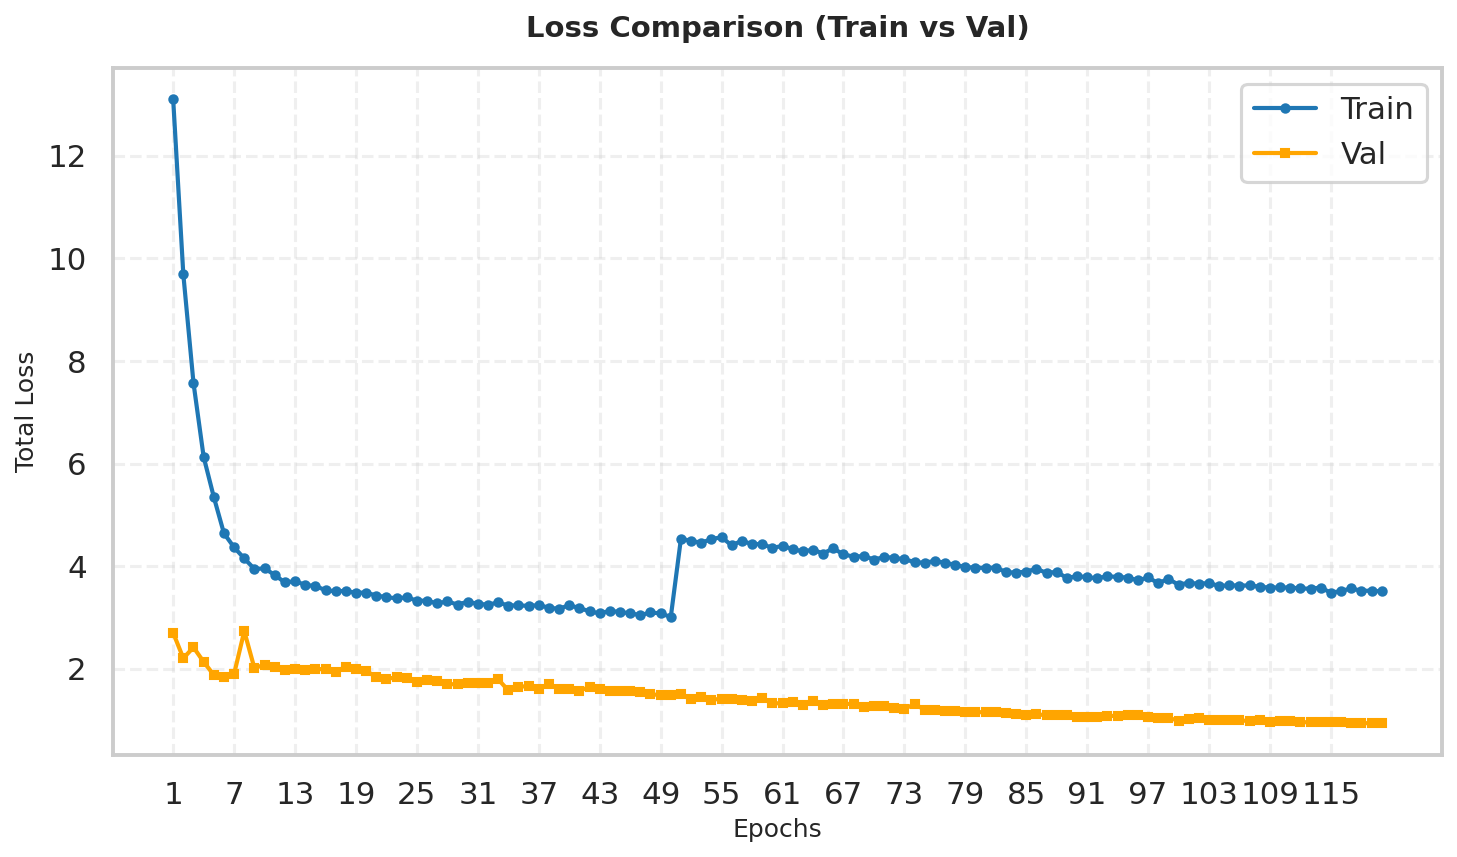

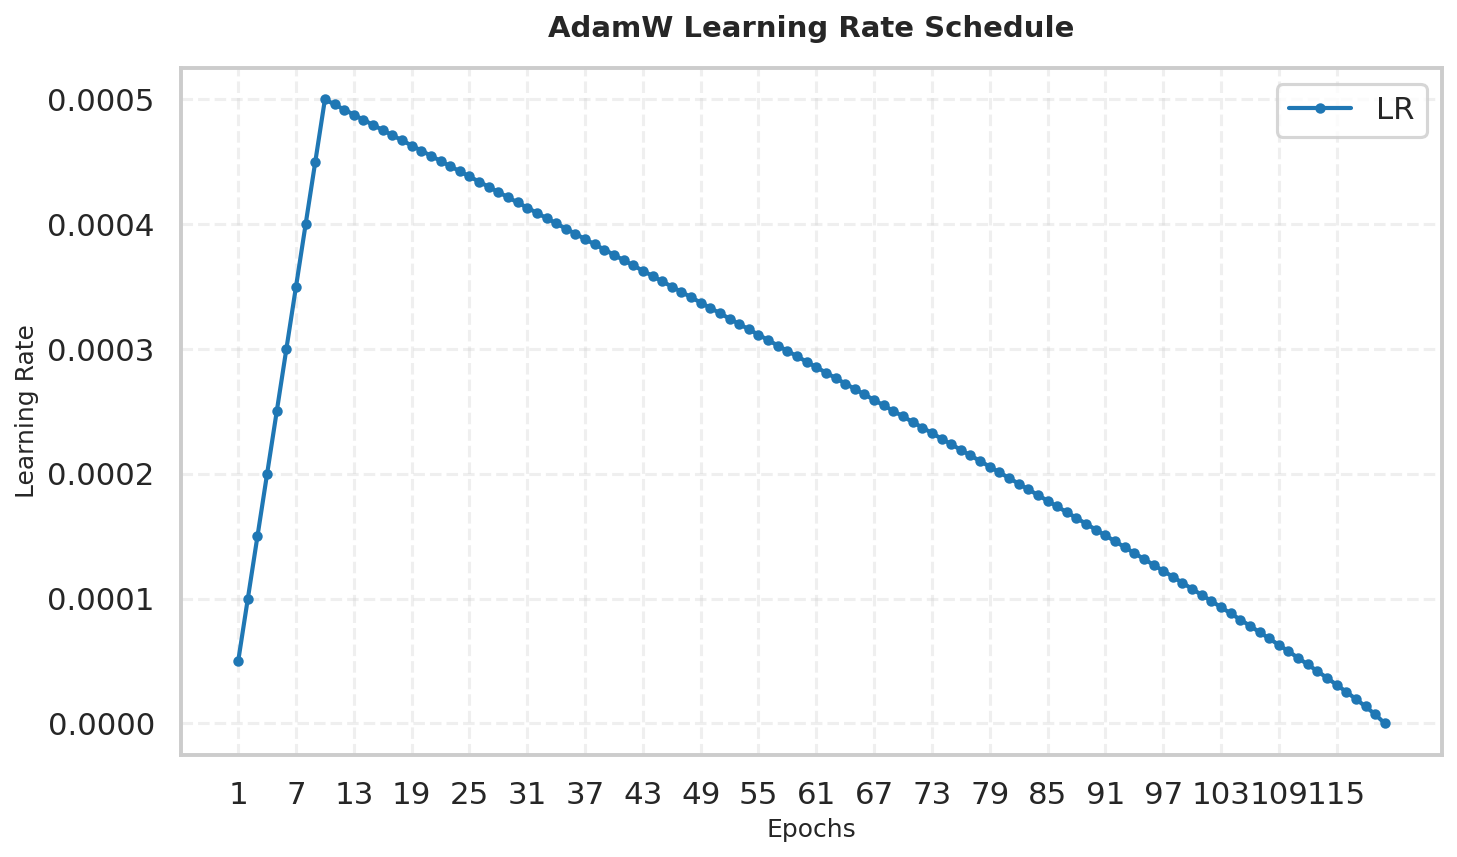

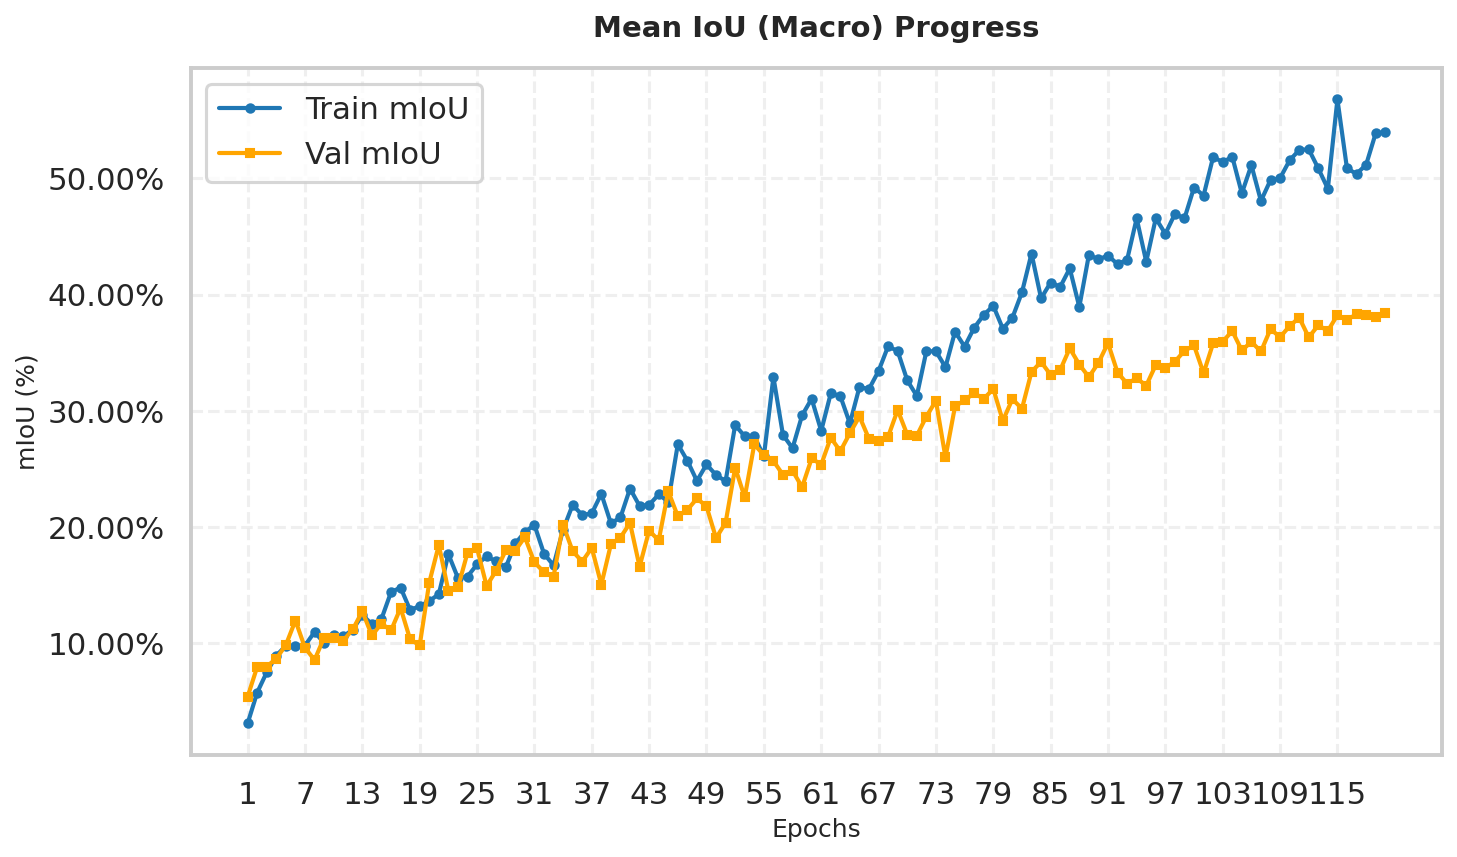

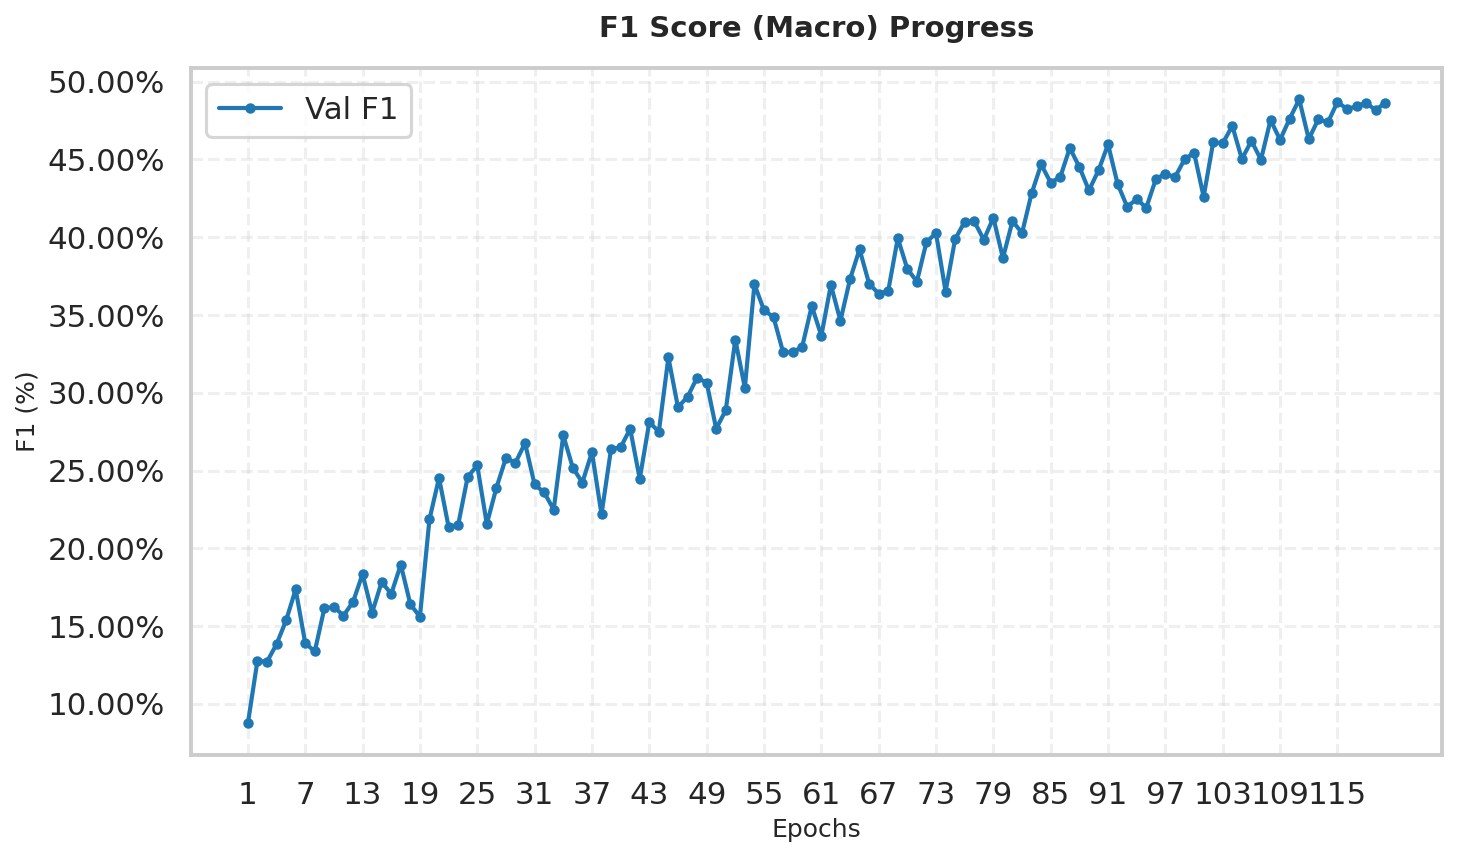

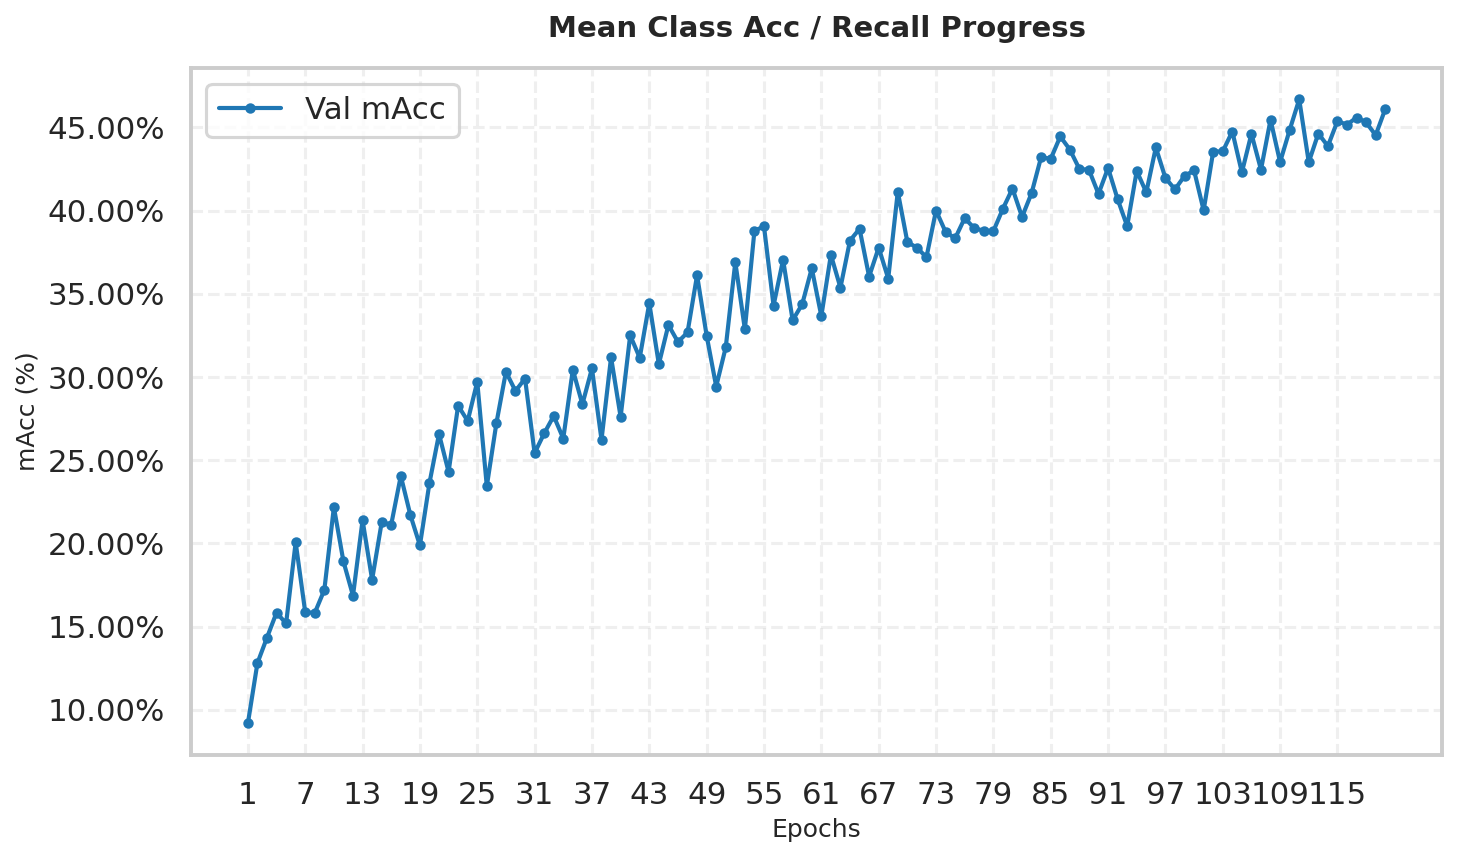

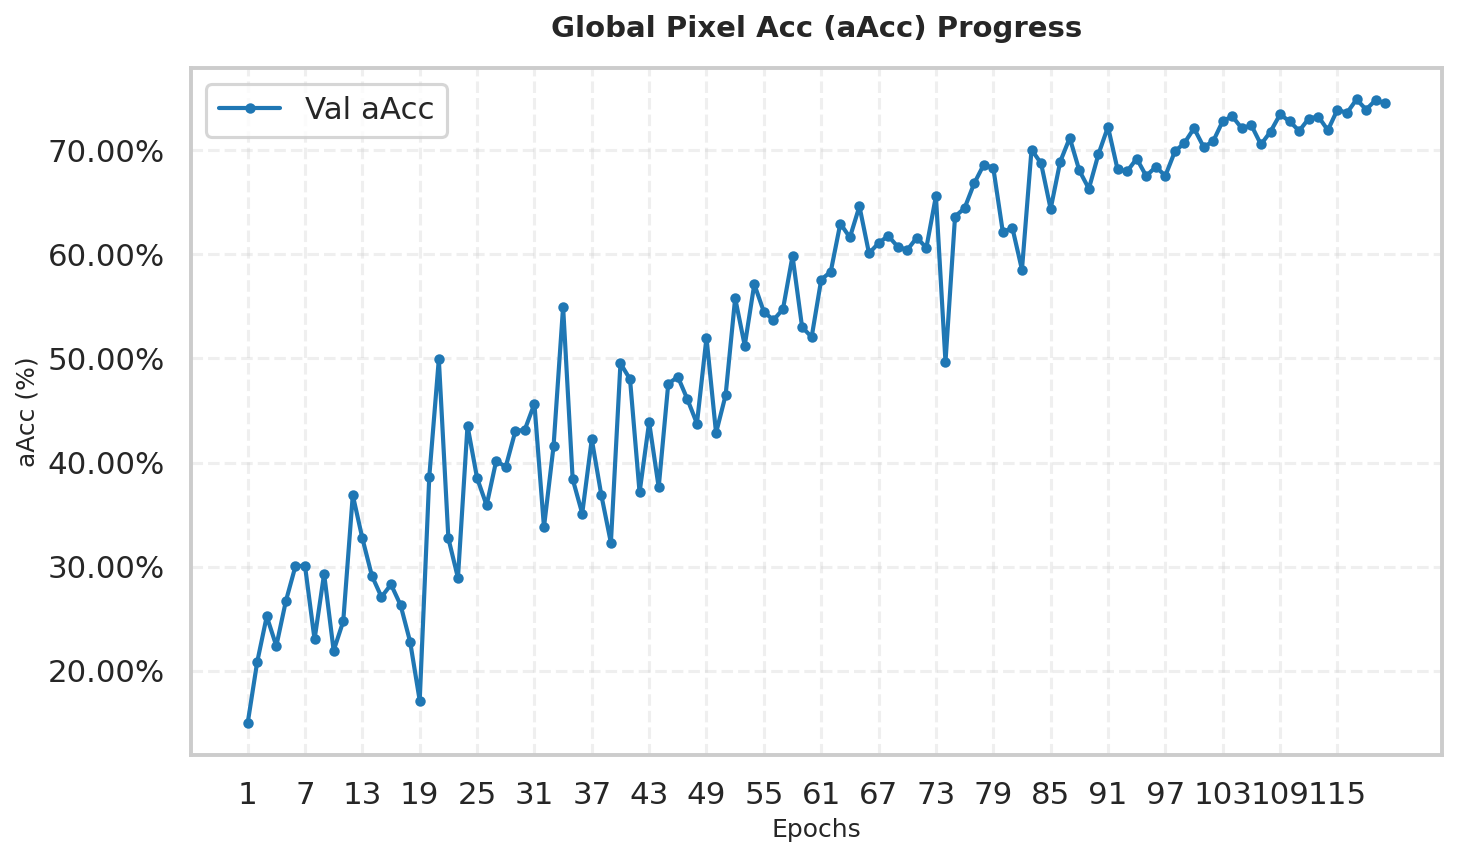

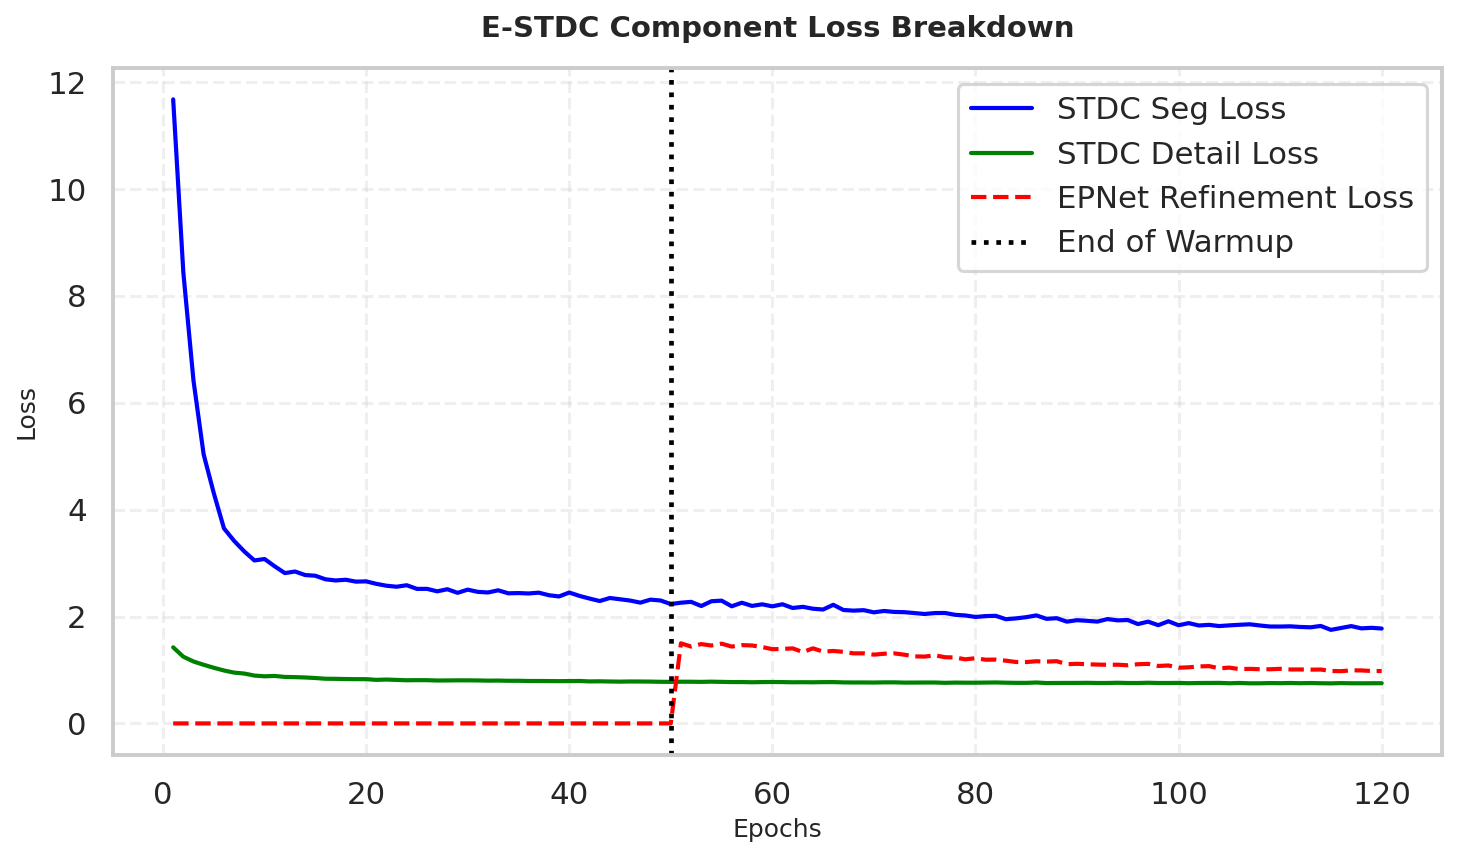


-------------------------------------------------------------------------------------
Architecture: E-STDC (STDC Base + EPNet Postprocessing)
Dataset: KITTI Semantic Segmentation Benchmark
Loss Config: Multi-Loss (Seg + Detail + EPNet) with Two-Stage Warmup
Total Parameters:      6,765,464  (6.77 M)
Trainable Parameters:  6,765,464  (6.77 M)
-------------------------------------------------------------------------------------
SUCCESS: All artifacts and graphs routed to:
/home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti

FINAL RESULTS (E-STDC Architecture)
Best Validation mIoU (Macro):     38.43% (Epoch 120)
Final Epoch Pixel Acc (aAcc):     74.50%
Final Epoch Mean Class Acc (mAcc):46.09%
Final Epoch F1-Score (Macro):     48.66%
Final Epoch Recall (Macro):       46.09%
Total Training Time:              0:57:14
-------------------------------------------------------------------------------------
CLASS NAME         | IoU (%)      | F1-Score (%)   | Precision (%)  

In [7]:
# ============================================================
# STEP 6: EXPORT RESULTS, PLOTS, CONFUSION MATRIX, FINAL SUMMARY
# Target Architecture: E-STDC (STDC Base + EPNet Postprocessing) #
# Target Dataset: KITTI #
# Optimized for: Automated Matrix Reconstruction, Class-Wise Parsing, 
# Percentage Matrices, Continuous Metric Plotting, Multi-Loss Visualization
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm import tqdm
import torch.nn.functional as F

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record", "DEVICE"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("/home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti"))
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"[*] Final export directory validated: {FINAL_SAVE_DIR.resolve()}\n")

# ------------------------------------------------------------
# AUTOMATED MATRIX RECOVERY PROTOCOL (CRASH PROOF)
# ------------------------------------------------------------
BEST_CONF_MATRIX = globals().get("best_conf_matrix", globals().get("val_conf_matrix", None))

if BEST_CONF_MATRIX is None and "val_loader" in globals() and "model" in globals():
    print("[!] Confusion matrix missing from RAM. Reconstructing from Best Checkpoint...")
    # FIXED: Pointing to the specific KITTI checkpoint
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, "best_model_estdc_kitti.pt")
    
    if os.path.exists(best_ckpt_path):
        ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        
        reconstructed_cm = np.zeros((CLASSES, CLASSES), dtype=np.int64)
        
        def _fast_confusion_matrix(y_true, y_pred, num_classes):
            idx = num_classes * y_true + y_pred
            return np.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)
        
        USE_AMP = torch.cuda.is_available()
        pbar = tqdm(val_loader, total=len(val_loader), desc="Reconstructing Metrics (E-STDC KITTI)", leave=False)
        
        with torch.no_grad():
            for images, masks in pbar:
                images = images.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)
                _, _, val_h, val_w = images.shape
                
                with torch.autocast(device_type="cuda", enabled=USE_AMP):
                    logits = model(images)
                    
                    # FIXED: Safe tuple unpacking
                    if isinstance(logits, (tuple, list)):
                        logits = logits[0]
                        
                    logits_up = F.interpolate(logits, size=(val_h, val_w), mode="bilinear", align_corners=False)
                    
                    if globals().get("USE_FLIP_TTA", False):
                        flip_logits = model(torch.flip(images, dims=[3]))
                        if isinstance(flip_logits, (tuple, list)):
                            flip_logits = flip_logits[0]
                            
                        flip_logits_up = F.interpolate(flip_logits, size=(val_h, val_w), mode="bilinear", align_corners=False)
                        logits_up = (logits_up + torch.flip(flip_logits_up, dims=[3])) / 2.0
                        
                preds = torch.argmax(logits_up, dim=1).cpu().numpy().astype(np.int64)
                targets_np = masks.cpu().numpy().astype(np.int64)
                
                # FIXED: Strict KITTI valid bounds checking
                valid = (targets_np >= 0) & (targets_np < CLASSES)
                if valid.any():
                    reconstructed_cm += _fast_confusion_matrix(targets_np[valid], preds[valid], CLASSES)
                    
        BEST_CONF_MATRIX = reconstructed_cm
        print("[*] Reconstruction Complete! Restoring class-wise scores.")
    else:
        print("[!] Could not locate best checkpoint on disk. Class-wise metrics will remain empty.")

# ------------------------------------------------------------
# BUILD MAIN DATAFRAME
# ------------------------------------------------------------
num_epochs = len(history.get("epoch", []))

def get_hist_col(key, fallback_key=None):
    col = history.get(key, [])
    if len(col) == num_epochs: return col
    if fallback_key and len(history.get(fallback_key, [])) == num_epochs: return history[fallback_key]
    if len(col) > 0:
        return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Train_Total_Loss": get_hist_col("train_total_loss"),
    "Train_Seg_Loss": get_hist_col("train_seg_loss"),       # STDC Main Loss #
    "Train_Detail_Loss": get_hist_col("train_detail_loss"), # STDC Detail Loss #
    "Train_EPNet_Loss": get_hist_col("train_epnet_loss"),   # EPNet Refinement Loss #
    "Train_mIoU": get_hist_col("train_mIoU_Macro", fallback_key="train_miou"),
    "Val_Total_Loss": get_hist_col("val_total_loss"),
    "Val_mIoU": get_hist_col("val_mIoU_Macro", fallback_key="val_miou"),
    "Val_F1_Macro": get_hist_col("val_F1_Macro"),
    "Val_Precision_Macro": get_hist_col("val_Precision_Macro"),
    "Val_Recall_Macro": get_hist_col("val_Recall_Macro", fallback_key="val_macc"),
    "Val_Micro_mIoU": get_hist_col("val_mIoU_Micro", fallback_key="val_aacc"),
    "Learning_Rate": get_hist_col("learning_rate"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

total_training_time_sec = float(df["Epoch_Time_sec"].sum()) if not df["Epoch_Time_sec"].isna().all() else 0.0
total_time_str = str(timedelta(seconds=int(total_training_time_sec)))
df["Total_Training_Session_Time"] = total_time_str

# ------------------------------------------------------------
# PREPARE EXHAUSTIVE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_CONF_MATRIX is not None:
    tp = np.diag(BEST_CONF_MATRIX)
    fp = BEST_CONF_MATRIX.sum(axis=0) - tp
    fn = BEST_CONF_MATRIX.sum(axis=1) - tp
    
    iou_per_class = tp / np.maximum(tp + fp + fn, 1)
    precision_per_class = tp / np.maximum(tp + fp, 1)
    recall_per_class = tp / np.maximum(tp + fn, 1)
    f1_per_class = 2 * (precision_per_class * recall_per_class) / np.maximum(precision_per_class + recall_per_class, 1e-10)
    
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": float(iou_per_class[i] * 100),
            "F1-Score (%)": float(f1_per_class[i] * 100),
            "Precision (%)": float(precision_per_class[i] * 100),
            "Recall (%)": float(recall_per_class[i] * 100)
        })

# ------------------------------------------------------------
# EXPORT FINAL RESULTS CSV & EXCEL
# ------------------------------------------------------------
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val if val > 1.0 else val * 100.0

final_micro_miou = safe_pct(df["Val_Micro_mIoU"].iloc[-1]) 
final_mIoU = safe_pct(df["Val_mIoU"].iloc[-1])
final_mRecall = safe_pct(df["Val_Recall_Macro"].iloc[-1])  
final_mF1 = safe_pct(df["Val_F1_Macro"].iloc[-1])

best_miou = safe_pct(best_record.get("best_miou", 0.0))
best_epoch = best_record.get("best_epoch", -1)

final_global_data = [
    {"Metric": "Best Validation mIoU (Macro)", "Value": f"{best_miou:.2f}%"},
    {"Metric": "Global Pixel Accuracy (aAcc)", "Value": f"{final_micro_miou:.2f}%"},
    {"Metric": "Final Epoch Mean Class Acc (mAcc)", "Value": f"{final_mRecall:.2f}%"},
    {"Metric": "Final Epoch Mean Recall (Macro)", "Value": f"{final_mRecall:.2f}%"},
    {"Metric": "Final Epoch Mean F1 Score (Macro)", "Value": f"{final_mF1:.2f}%"},
    {"Metric": "Total Training Time", "Value": total_time_str}
]
pd.DataFrame(final_global_data).to_csv(FINAL_SAVE_DIR / "finalresults_estdc_kitti.csv", index=False)

excel_path = FINAL_SAVE_DIR / "Training_Metrics_Report_ESTDC_KITTI.xlsx"
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
    if class_wise_data:
        pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise_Results', index=False)

# ------------------------------------------------------------
# STANDARD SEPARATE PLOTS (INDIVIDUAL METRICS)
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_separate_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val", is_percentage=False):
    plt.figure(figsize=(10, 6))
    
    epochs_range = df["Epoch"].dropna().values if not df["Epoch"].isna().all() else np.arange(1, len(train_data) + 1)
    train_clean = np.array(train_data, dtype=float)
    
    if not np.isnan(train_clean).all():
        plt.plot(epochs_range, train_clean, label=label1, lw=2, marker='o', markersize=4)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)
        if not np.isnan(val_clean).all():
            plt.plot(epochs_range, val_clean, label=label2, lw=2, marker='s', markersize=4, color='orange')
            
    if is_percentage:
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

    if len(epochs_range) > 0:
        plt.xticks(np.arange(min(epochs_range), max(epochs_range) + 1, step=max(1, len(epochs_range)//20)))

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# Extract Data
train_loss = df["Train_Total_Loss"].tolist()
val_loss = df["Val_Total_Loss"].tolist()
train_miou = df["Train_mIoU"].tolist()
val_miou = df["Val_mIoU"].tolist()
val_f1 = df["Val_F1_Macro"].tolist()
val_recall = df["Val_Recall_Macro"].tolist()
val_micro = df["Val_Micro_mIoU"].tolist()
learning_rate = df["Learning_Rate"].tolist()

# 1. Standard Plots
save_separate_plot("loss_comparison_kitti", "Loss Comparison (Train vs Val)", "Total Loss", train_loss, val_loss)
save_separate_plot("learning_rate_progress_kitti", "AdamW Learning Rate Schedule", "Learning Rate", learning_rate, label1="LR")
save_separate_plot("miou_progress_kitti", "Mean IoU (Macro) Progress", "mIoU (%)", train_miou, val_miou, label1="Train mIoU", label2="Val mIoU", is_percentage=True)
save_separate_plot("f1_progress_kitti", "F1 Score (Macro) Progress", "F1 (%)", val_f1, label1="Val F1", is_percentage=True)
save_separate_plot("recall_progress_kitti", "Mean Class Acc / Recall Progress", "mAcc (%)", val_recall, label1="Val mAcc", is_percentage=True)
save_separate_plot("micro_miou_progress_kitti", "Global Pixel Acc (aAcc) Progress", "aAcc (%)", val_micro, label1="Val aAcc", is_percentage=True)

# 2. Specialized Plot: E-STDC Component Loss Breakdown
plt.figure(figsize=(10, 6))
epochs_range = df["Epoch"].dropna().values if not df["Epoch"].isna().all() else np.arange(1, len(train_loss) + 1)
plt.plot(epochs_range, df["Train_Seg_Loss"], label="STDC Seg Loss", lw=2, color='blue')
plt.plot(epochs_range, df["Train_Detail_Loss"], label="STDC Detail Loss", lw=2, color='green')
plt.plot(epochs_range, df["Train_EPNet_Loss"], label="EPNet Refinement Loss", lw=2, color='red', linestyle='--')
plt.axvline(x=globals().get("WARMUP_EPOCHS", 50), color='black', linestyle=':', label='End of Warmup')
plt.title("E-STDC Component Loss Breakdown", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(FINAL_SAVE_DIR / "estdc_loss_breakdown_kitti.png", dpi=600, bbox_inches='tight')
plt.show()
plt.close()

# ------------------------------------------------------------
# PERCENTAGE-BASED CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(20, 16)) 
    
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    sns.heatmap(
        cm_normalized, annot=True, fmt='.1%', cmap='Blues', 
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
        annot_kws={"size": 10}
    ) 
    
    plt.title(f"E-STDC on KITTI: Confusion Matrix (Best Epoch {best_epoch})", fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Class', fontsize=14)
    plt.xlabel('Predicted Class', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / "confusion_matrix_percentages_kitti.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# ------------------------------------------------------------
# FINAL PRINT SUMMARY
# ------------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n" + "-"*85)
print(f"Architecture: E-STDC (STDC Base + EPNet Postprocessing)") #
print(f"Dataset: KITTI Semantic Segmentation Benchmark")
print(f"Loss Config: Multi-Loss (Seg + Detail + EPNet) with Two-Stage Warmup") #
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print(f"-"*85)
print(f"SUCCESS: All artifacts and graphs routed to:\n{FINAL_SAVE_DIR.resolve()}")
print("\n" + "="*85)
print(f"FINAL RESULTS (E-STDC Architecture)")
print("="*85)
print(f"Best Validation mIoU (Macro):     {best_miou:.2f}% (Epoch {best_epoch})")
print(f"Final Epoch Pixel Acc (aAcc):     {final_micro_miou:.2f}%")
print(f"Final Epoch Mean Class Acc (mAcc):{final_mRecall:.2f}%")
print(f"Final Epoch F1-Score (Macro):     {final_mF1:.2f}%")
print(f"Final Epoch Recall (Macro):       {final_mRecall:.2f}%")
print(f"Total Training Time:              {total_time_str}")
print("-" * 85)
print(f"{'CLASS NAME':<18} | {'IoU (%)':<12} | {'F1-Score (%)':<14} | {'Precision (%)':<14} | {'Recall (%)':<12}")
print("-" * 85)

if class_wise_data:
    for item in class_wise_data:
        print(f"{item['Class Name']:<18} | {item['IoU (%)']:<12.2f} | {item['F1-Score (%)']:<14.2f} | {item['Precision (%)']:<14.2f} | {item['Recall (%)']:<12.2f}")

[*] Final export directory validated: /home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti

[!] Confusion matrix missing from RAM. Reconstructing from Best Checkpoint...


[*] Reconstruction Complete! Restoring class-wise scores.


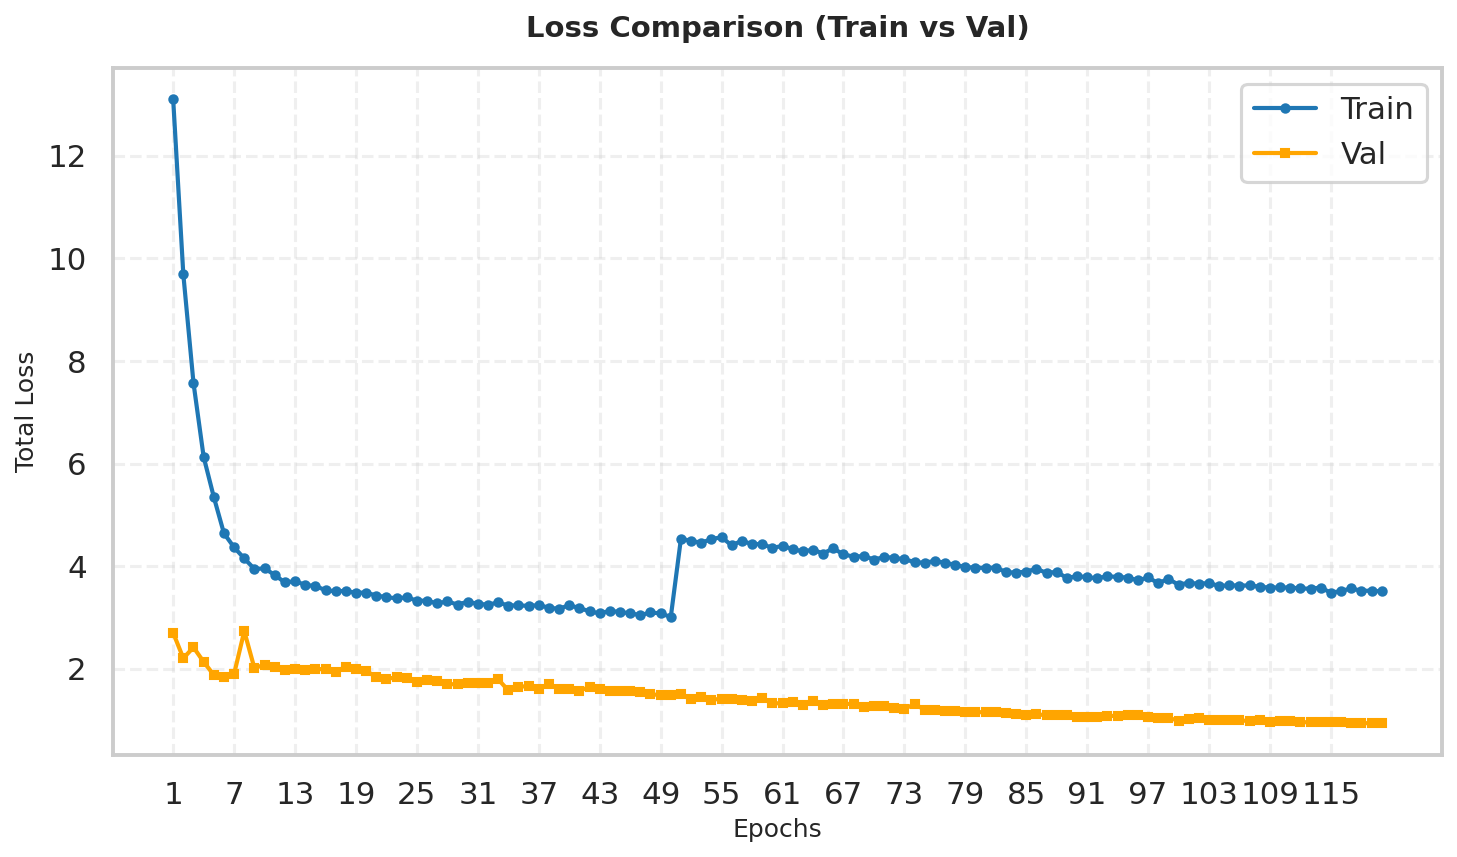

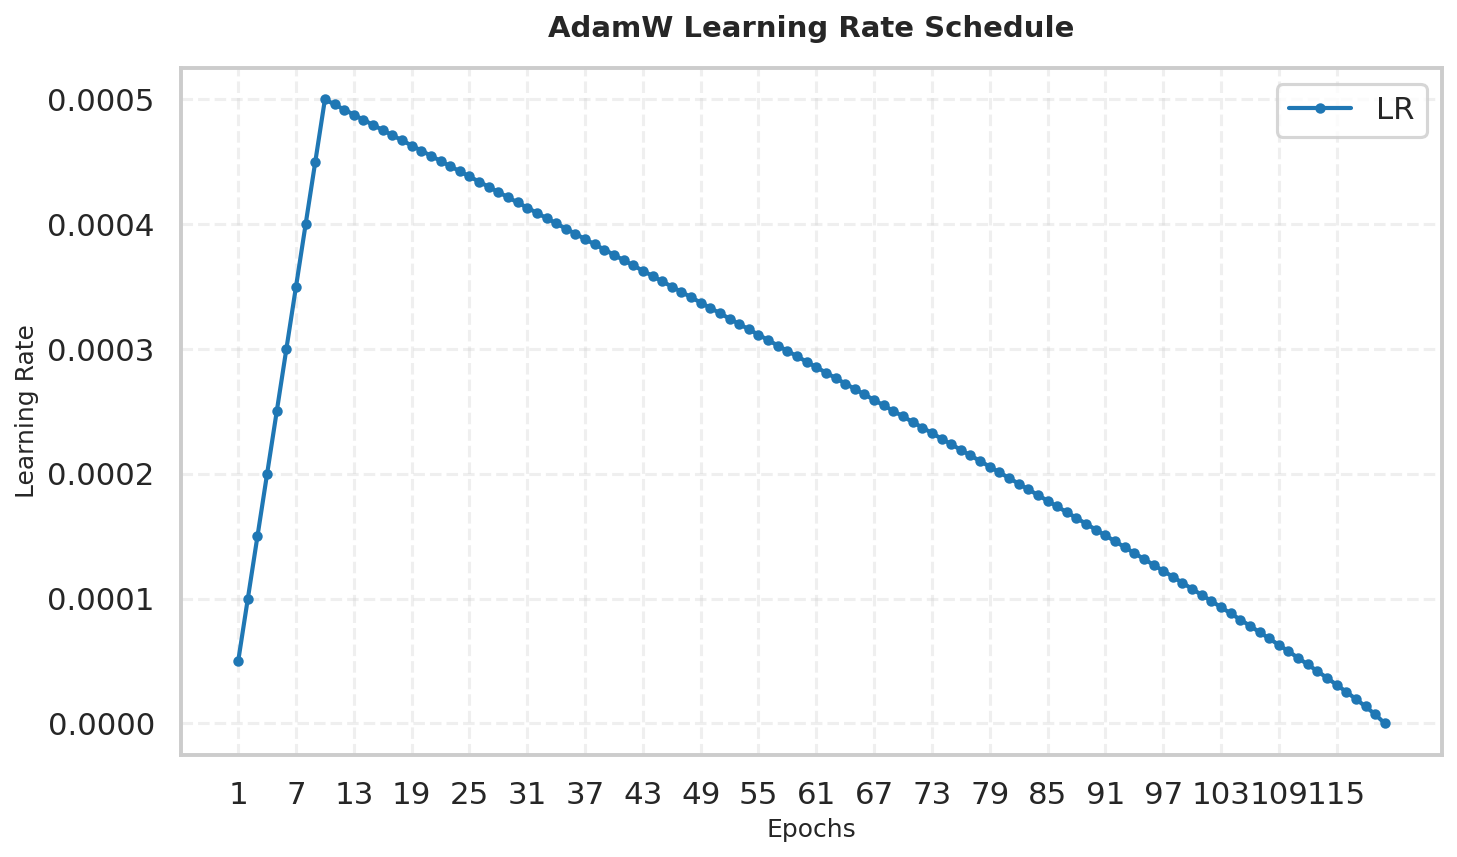

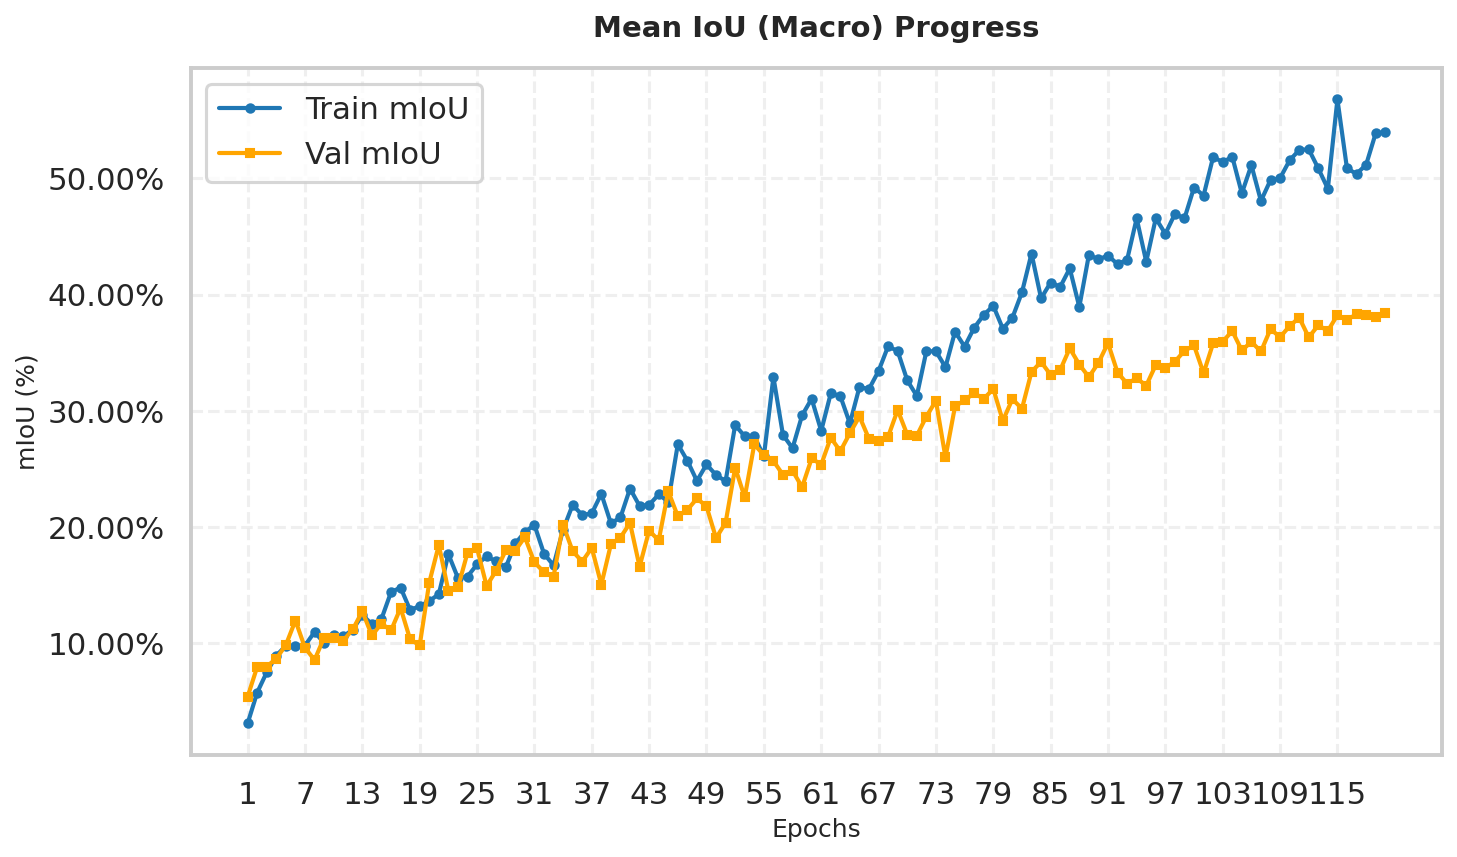

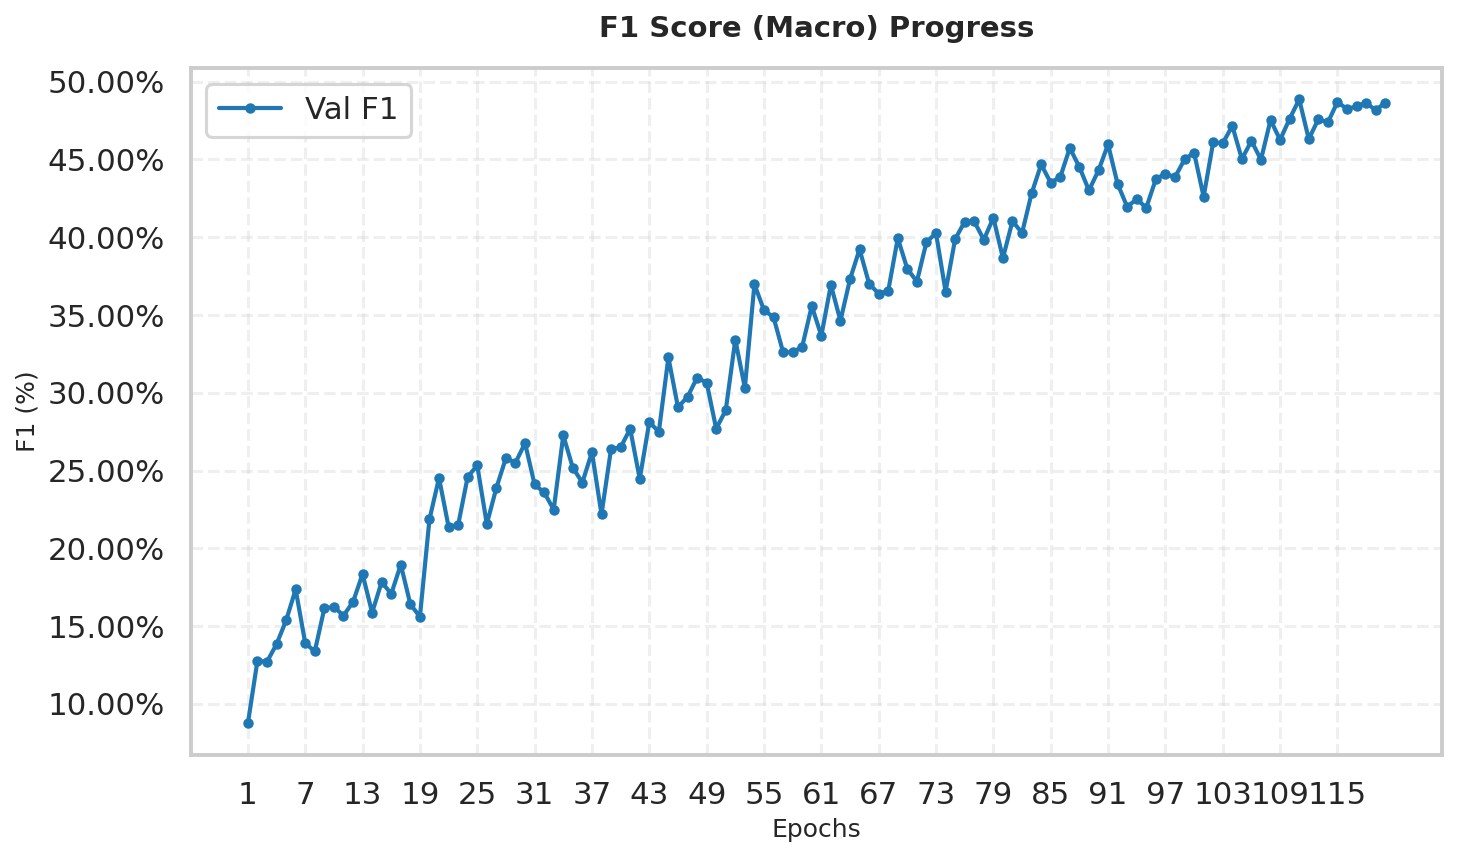

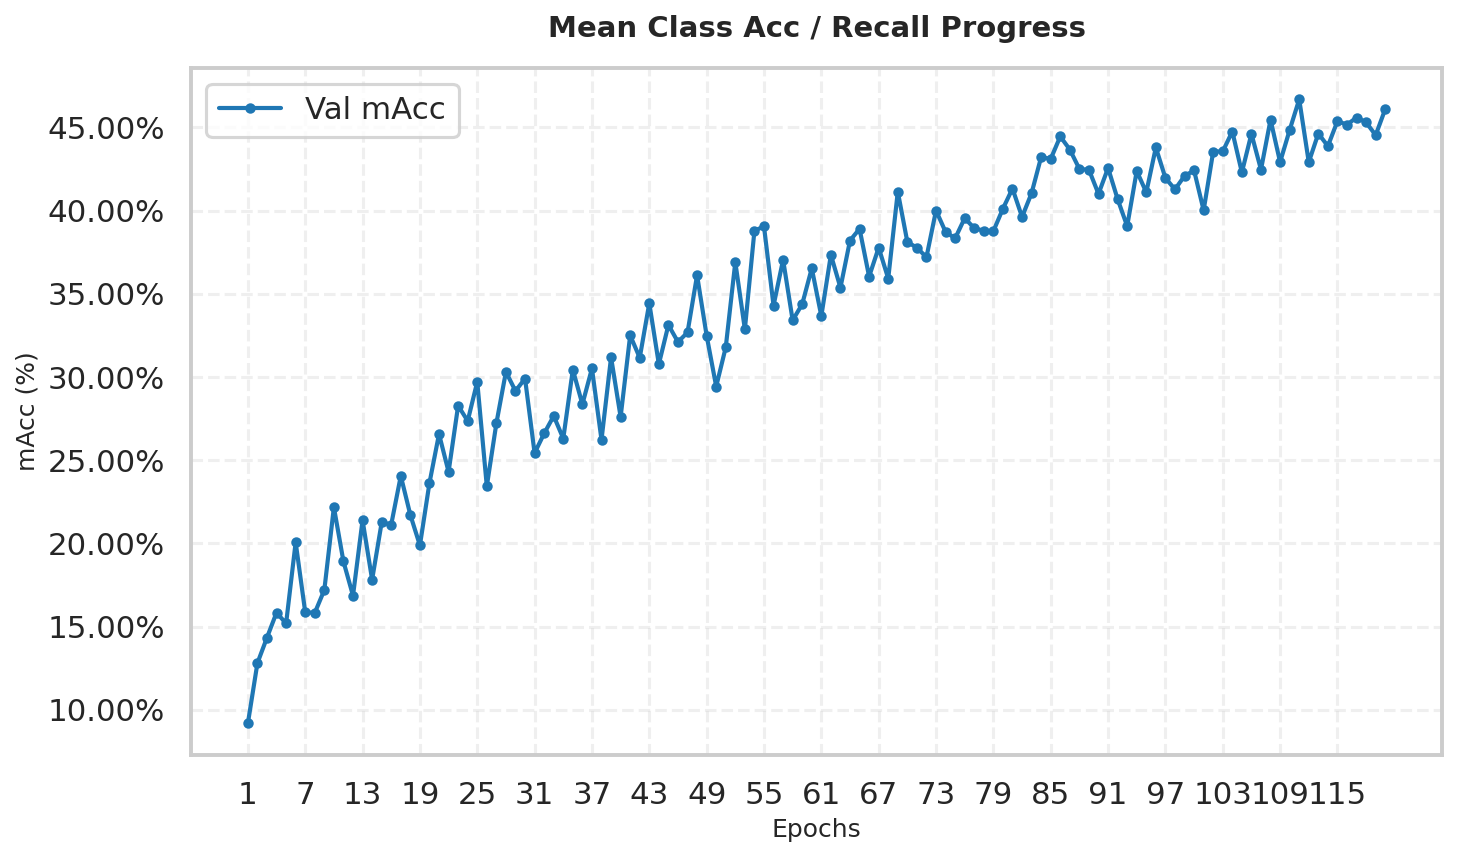

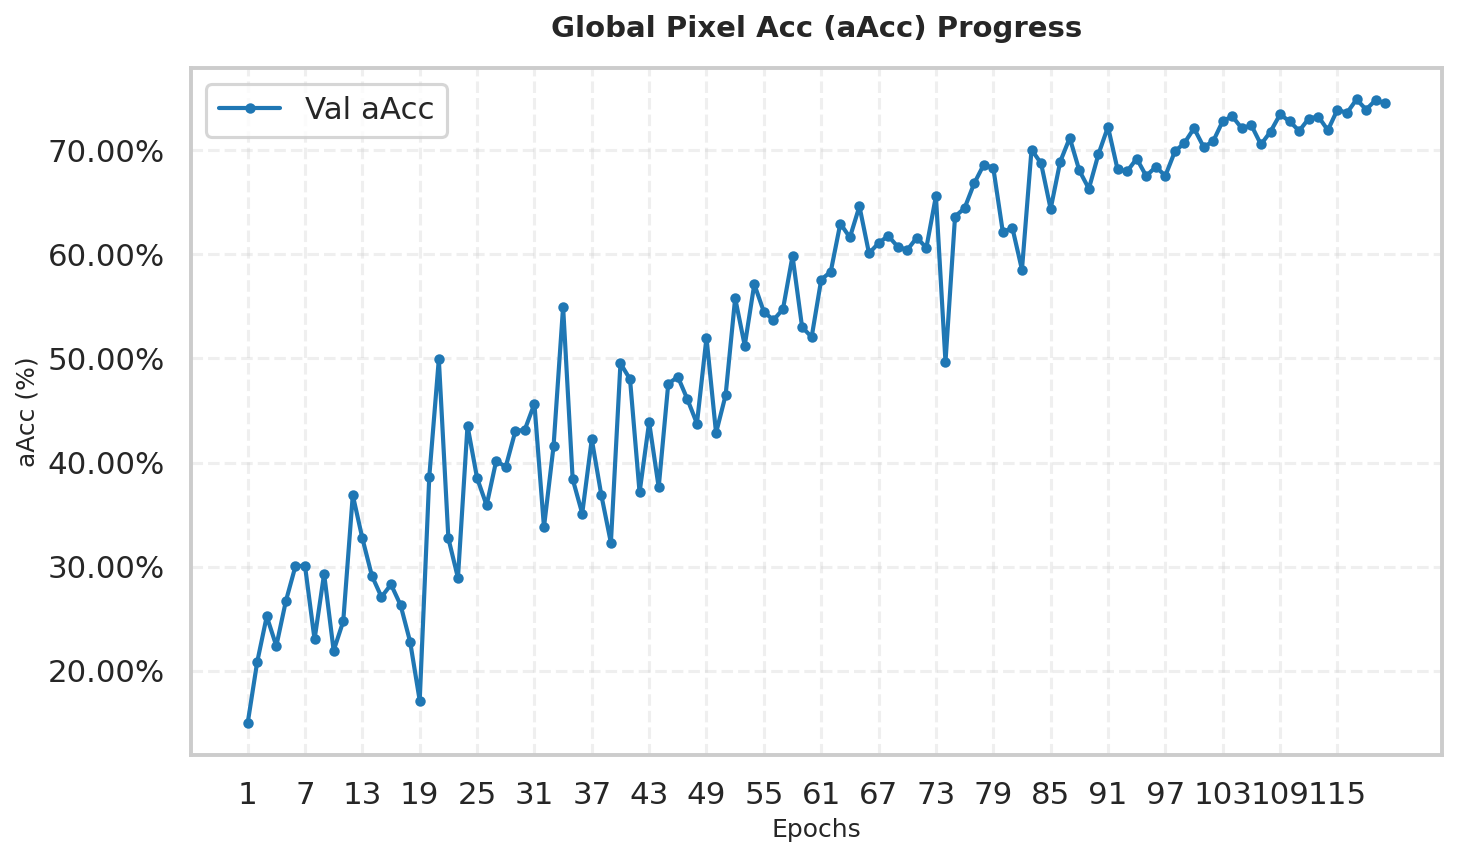

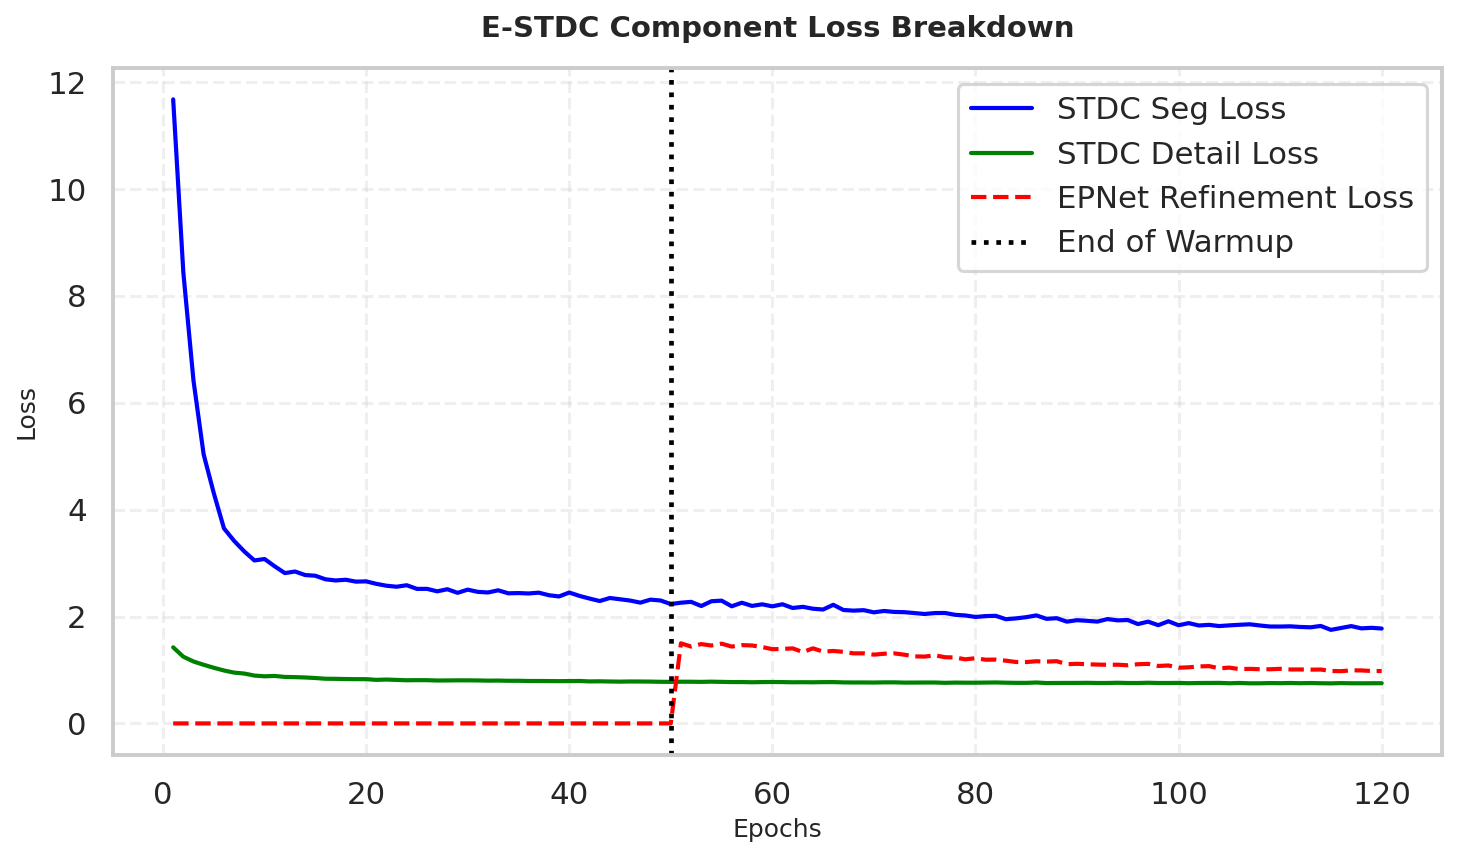

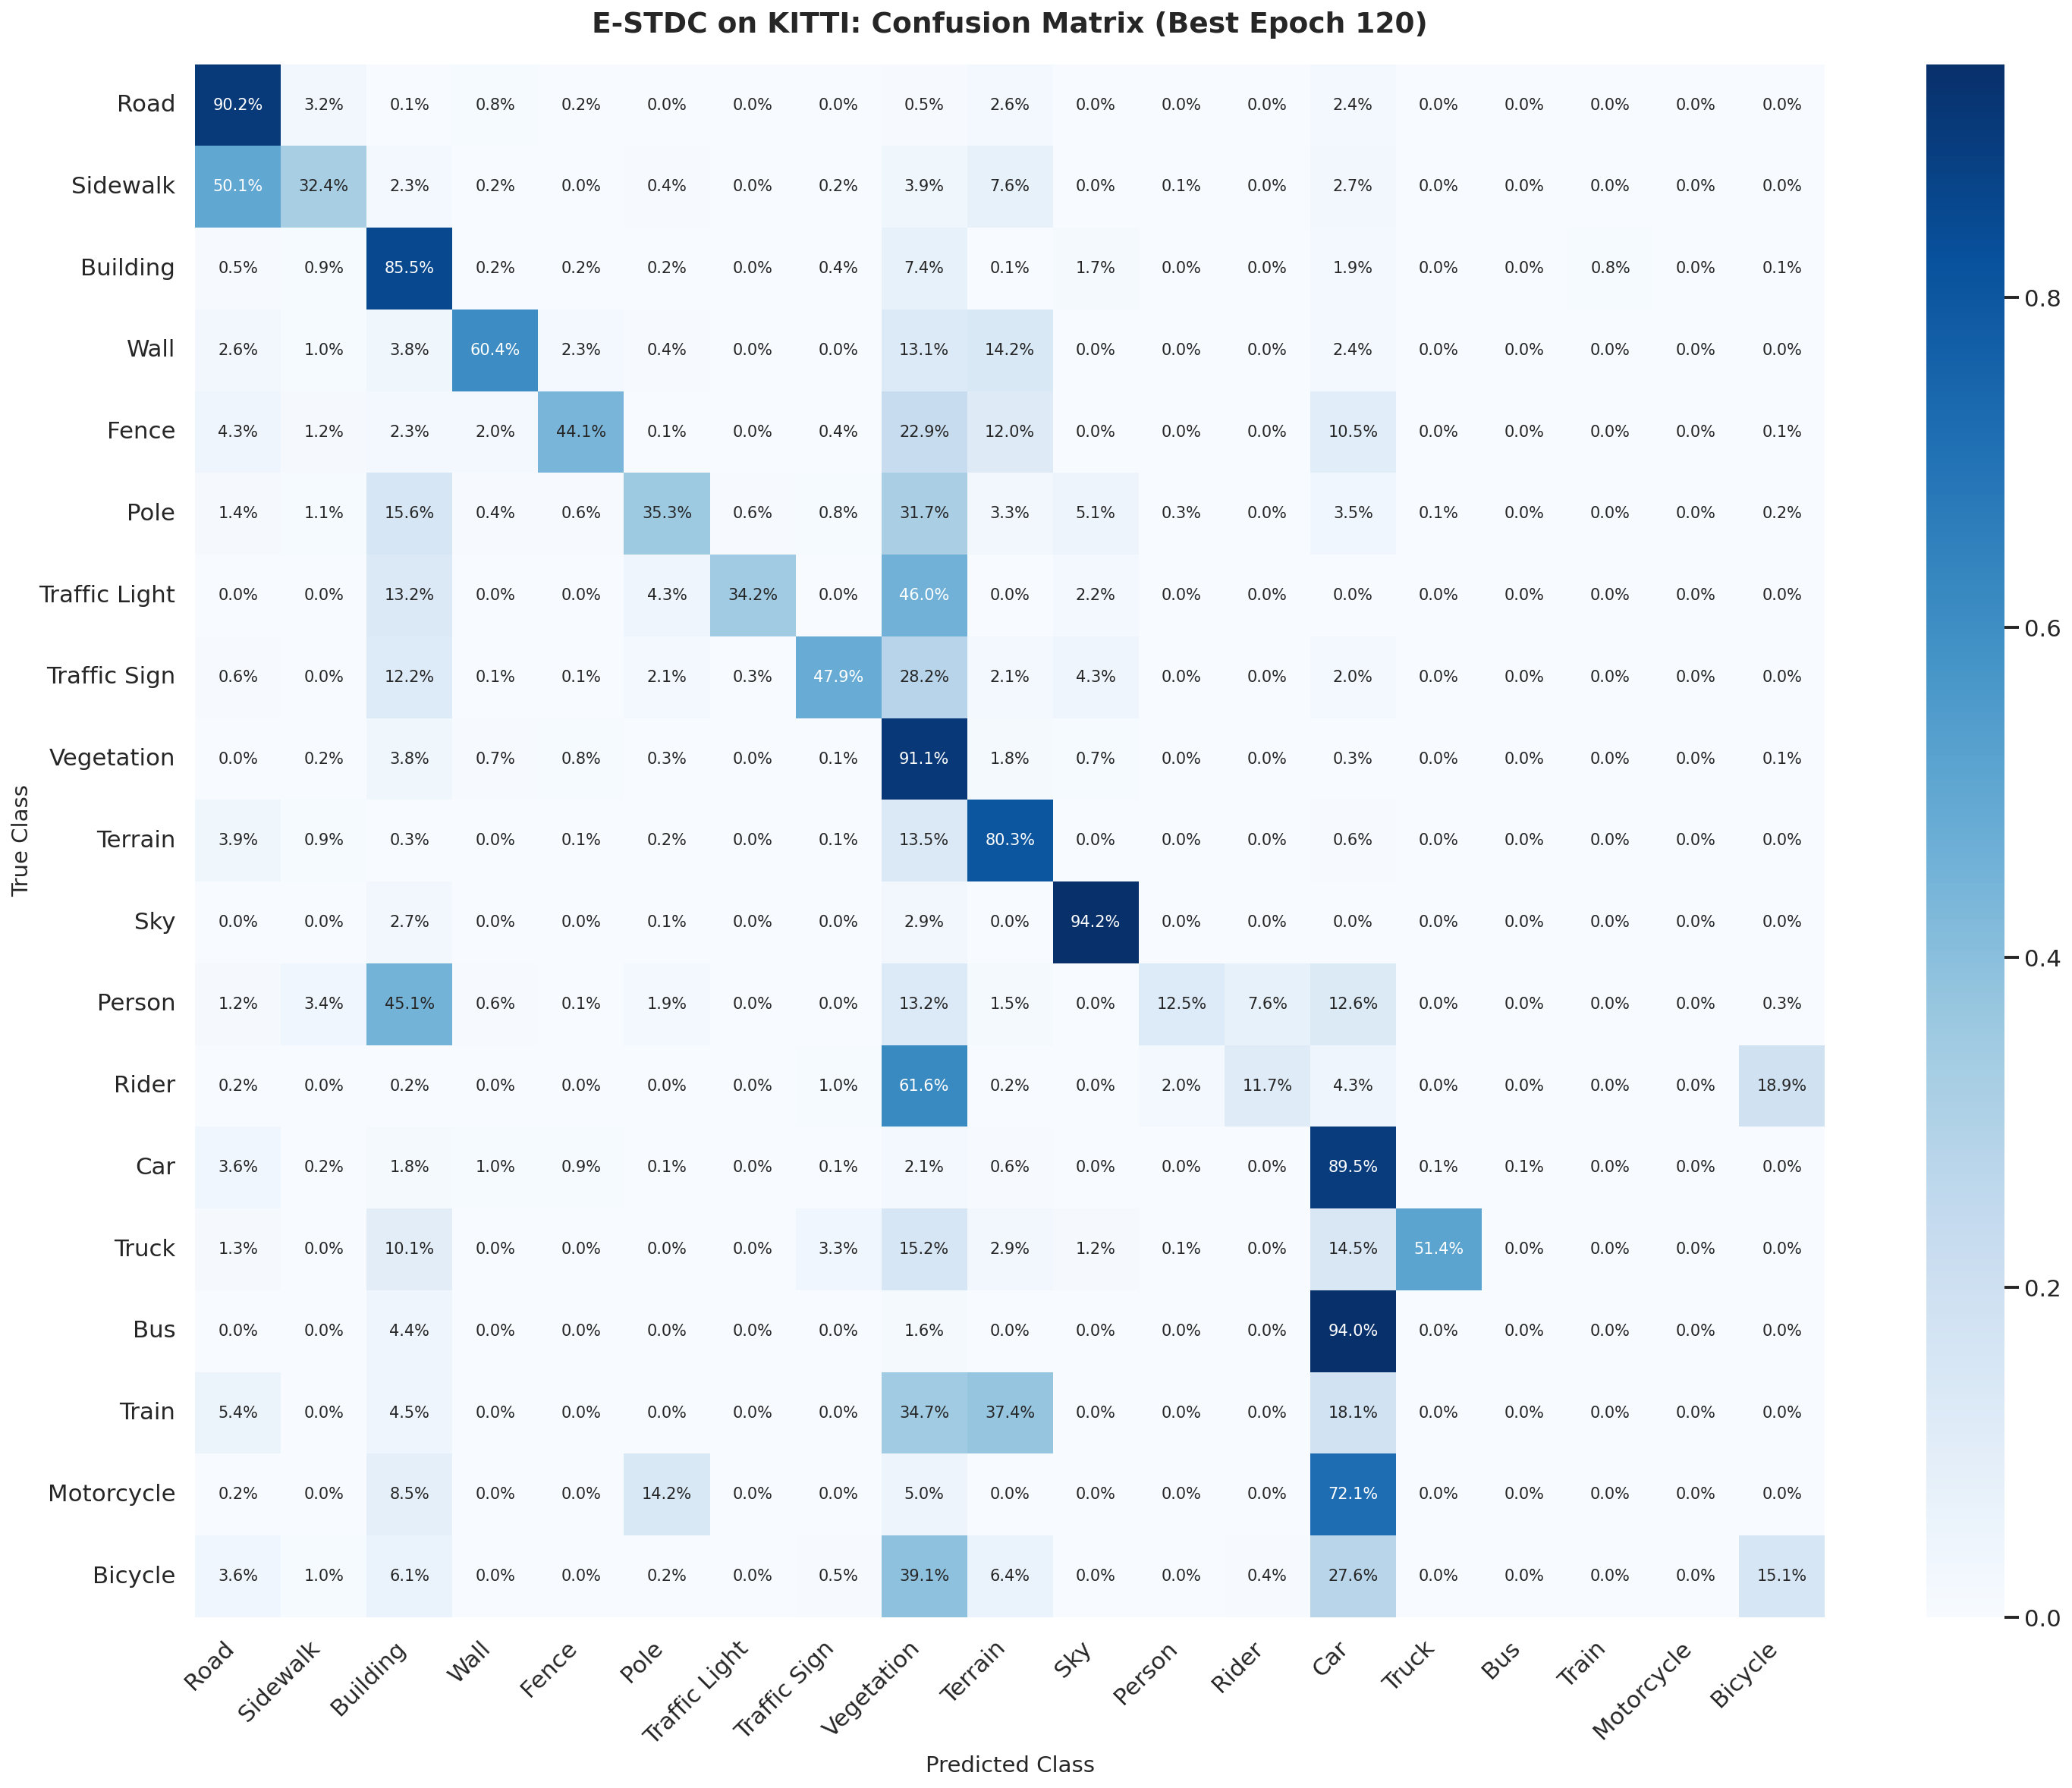


-------------------------------------------------------------------------------------
Architecture: E-STDC (STDC Base + EPNet Postprocessing)
Dataset: KITTI Semantic Segmentation Benchmark
Loss Config: Multi-Loss (Seg + Detail + EPNet) with Two-Stage Warmup
Total Parameters:      6,765,464  (6.77 M)
Trainable Parameters:  6,765,464  (6.77 M)
-------------------------------------------------------------------------------------
SUCCESS: All artifacts and graphs routed to:
/home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti

FINAL RESULTS (E-STDC Architecture)
Best Validation mIoU (Macro):     38.43% (Epoch 120)
Final Epoch Pixel Acc (aAcc):     74.50%
Final Epoch Mean Class Acc (mAcc):46.09%
Final Epoch F1-Score (Macro):     48.66%
Final Epoch Recall (Macro):       46.09%
Total Training Time:              0:57:14
-------------------------------------------------------------------------------------
CLASS NAME         | IoU (%)      | F1-Score (%)   | Precision (%)  

In [8]:
# ============================================================
# STEP 6: EXPORT RESULTS, PLOTS, CONFUSION MATRIX, FINAL SUMMARY
# Target Architecture: E-STDC (STDC Base + EPNet Postprocessing)
# Target Dataset: KITTI
# Optimized for: Automated Matrix Reconstruction, Class-Wise Parsing, 
# Percentage Matrices, Continuous Metric Plotting, Multi-Loss Visualization
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm import tqdm
import torch.nn.functional as F

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES", "DEVICE"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("/home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti"))
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"[*] Final export directory validated: {FINAL_SAVE_DIR.resolve()}\n")

# ------------------------------------------------------------
# AUTOMATED MATRIX RECOVERY PROTOCOL (CRASH PROOF)
# ------------------------------------------------------------
BEST_CONF_MATRIX = globals().get("best_conf_matrix", globals().get("val_conf_matrix", None))

if BEST_CONF_MATRIX is None and "val_loader" in globals() and "model" in globals():
    print("[!] Confusion matrix missing from RAM. Reconstructing from Best Checkpoint...")
    
    # FIXED: Pointing exactly to where Step 5 saves the best model
    best_ckpt_path = FINAL_SAVE_DIR / "best_model_estdc_kitti.pt"
    
    if best_ckpt_path.exists():
        ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        
        reconstructed_cm = np.zeros((CLASSES, CLASSES), dtype=np.int64)
        
        def _fast_confusion_matrix(y_true, y_pred, num_classes):
            idx = num_classes * y_true + y_pred
            return np.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)
        
        USE_AMP = torch.cuda.is_available()
        pbar = tqdm(val_loader, total=len(val_loader), desc="Reconstructing Metrics (E-STDC KITTI)", leave=False)
        
        with torch.no_grad():
            for images, masks in pbar:
                images = images.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)
                _, _, val_h, val_w = images.shape
                
                with torch.autocast(device_type="cuda", enabled=USE_AMP):
                    logits = model(images)
                    
                    # Safe tuple unpacking
                    if isinstance(logits, (tuple, list)):
                        logits = logits[0]
                        
                    logits_up = F.interpolate(logits, size=(val_h, val_w), mode="bilinear", align_corners=False)
                    
                    if globals().get("USE_FLIP_TTA", False):
                        flip_logits = model(torch.flip(images, dims=[3]))
                        if isinstance(flip_logits, (tuple, list)):
                            flip_logits = flip_logits[0]
                            
                        flip_logits_up = F.interpolate(flip_logits, size=(val_h, val_w), mode="bilinear", align_corners=False)
                        logits_up = (logits_up + torch.flip(flip_logits_up, dims=[3])) / 2.0
                        
                preds = torch.argmax(logits_up, dim=1).cpu().numpy().astype(np.int64)
                targets_np = masks.cpu().numpy().astype(np.int64)
                
                # Strict KITTI valid bounds checking
                valid = (targets_np >= 0) & (targets_np < CLASSES)
                if valid.any():
                    reconstructed_cm += _fast_confusion_matrix(targets_np[valid], preds[valid], CLASSES)
                    
        BEST_CONF_MATRIX = reconstructed_cm
        print("[*] Reconstruction Complete! Restoring class-wise scores.")
    else:
        print(f"[!] Could not locate best checkpoint on disk at: {best_ckpt_path}")
        print("    Class-wise metrics will remain empty.")

# ------------------------------------------------------------
# BUILD MAIN DATAFRAME
# ------------------------------------------------------------
num_epochs = len(history.get("epoch", []))

def get_hist_col(key, fallback_key=None):
    col = history.get(key, [])
    if len(col) == num_epochs: return col
    if fallback_key and len(history.get(fallback_key, [])) == num_epochs: return history[fallback_key]
    if len(col) > 0:
        return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Train_Total_Loss": get_hist_col("train_total_loss"),
    "Train_Seg_Loss": get_hist_col("train_seg_loss"),
    "Train_Detail_Loss": get_hist_col("train_detail_loss"),
    "Train_EPNet_Loss": get_hist_col("train_epnet_loss"),
    "Train_mIoU": get_hist_col("train_mIoU_Macro", fallback_key="train_miou"),
    "Val_Total_Loss": get_hist_col("val_total_loss"),
    "Val_mIoU": get_hist_col("val_mIoU_Macro", fallback_key="val_miou"),
    "Val_F1_Macro": get_hist_col("val_F1_Macro"),
    "Val_Precision_Macro": get_hist_col("val_Precision_Macro"),
    "Val_Recall_Macro": get_hist_col("val_Recall_Macro", fallback_key="val_macc"),
    "Val_Micro_mIoU": get_hist_col("val_mIoU_Micro", fallback_key="val_aacc"),
    "Learning_Rate": get_hist_col("learning_rate"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

total_training_time_sec = float(df["Epoch_Time_sec"].sum()) if not df["Epoch_Time_sec"].isna().all() else 0.0
total_time_str = str(timedelta(seconds=int(total_training_time_sec)))
df["Total_Training_Session_Time"] = total_time_str

# ------------------------------------------------------------
# PREPARE EXHAUSTIVE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_CONF_MATRIX is not None:
    tp = np.diag(BEST_CONF_MATRIX)
    fp = BEST_CONF_MATRIX.sum(axis=0) - tp
    fn = BEST_CONF_MATRIX.sum(axis=1) - tp
    
    iou_per_class = tp / np.maximum(tp + fp + fn, 1)
    precision_per_class = tp / np.maximum(tp + fp, 1)
    recall_per_class = tp / np.maximum(tp + fn, 1)
    f1_per_class = 2 * (precision_per_class * recall_per_class) / np.maximum(precision_per_class + recall_per_class, 1e-10)
    
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": float(iou_per_class[i] * 100),
            "F1-Score (%)": float(f1_per_class[i] * 100),
            "Precision (%)": float(precision_per_class[i] * 100),
            "Recall (%)": float(recall_per_class[i] * 100)
        })

# ------------------------------------------------------------
# EXPORT FINAL RESULTS CSV & EXCEL
# ------------------------------------------------------------
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val if val > 1.0 else val * 100.0

final_micro_miou = safe_pct(df["Val_Micro_mIoU"].iloc[-1]) if not df.empty else 0.0
final_mIoU = safe_pct(df["Val_mIoU"].iloc[-1]) if not df.empty else 0.0
final_mRecall = safe_pct(df["Val_Recall_Macro"].iloc[-1]) if not df.empty else 0.0
final_mF1 = safe_pct(df["Val_F1_Macro"].iloc[-1]) if not df.empty else 0.0

best_miou = safe_pct(globals().get("best_record", {}).get("best_miou", 0.0))
best_epoch = globals().get("best_record", {}).get("best_epoch", -1)

final_global_data = [
    {"Metric": "Best Validation mIoU (Macro)", "Value": f"{best_miou:.2f}%"},
    {"Metric": "Global Pixel Accuracy (aAcc)", "Value": f"{final_micro_miou:.2f}%"},
    {"Metric": "Final Epoch Mean Class Acc (mAcc)", "Value": f"{final_mRecall:.2f}%"},
    {"Metric": "Final Epoch Mean Recall (Macro)", "Value": f"{final_mRecall:.2f}%"},
    {"Metric": "Final Epoch Mean F1 Score (Macro)", "Value": f"{final_mF1:.2f}%"},
    {"Metric": "Total Training Time", "Value": total_time_str}
]
pd.DataFrame(final_global_data).to_csv(FINAL_SAVE_DIR / "finalresults_estdc_kitti.csv", index=False)

excel_path = FINAL_SAVE_DIR / "Training_Metrics_Report_ESTDC_KITTI.xlsx"
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
    if class_wise_data:
        pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise_Results', index=False)

# ------------------------------------------------------------
# STANDARD SEPARATE PLOTS (INDIVIDUAL METRICS)
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_separate_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val", is_percentage=False):
    plt.figure(figsize=(10, 6))
    
    epochs_range = df["Epoch"].dropna().values if not df["Epoch"].isna().all() else np.arange(1, len(train_data) + 1)
    train_clean = np.array(train_data, dtype=float)
    
    if not np.isnan(train_clean).all():
        plt.plot(epochs_range, train_clean, label=label1, lw=2, marker='o', markersize=4)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)
        if not np.isnan(val_clean).all():
            plt.plot(epochs_range, val_clean, label=label2, lw=2, marker='s', markersize=4, color='orange')
            
    if is_percentage:
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

    if len(epochs_range) > 0:
        plt.xticks(np.arange(min(epochs_range), max(epochs_range) + 1, step=max(1, len(epochs_range)//20)))

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    # Use close instead of show if running in automated scripts to prevent hanging, 
    # but we'll show here for notebooks
    plt.show() 
    plt.close()

if not df.empty:
    # Extract Data
    train_loss = df["Train_Total_Loss"].tolist()
    val_loss = df["Val_Total_Loss"].tolist()
    train_miou = df["Train_mIoU"].tolist()
    val_miou = df["Val_mIoU"].tolist()
    val_f1 = df["Val_F1_Macro"].tolist()
    val_recall = df["Val_Recall_Macro"].tolist()
    val_micro = df["Val_Micro_mIoU"].tolist()
    learning_rate = df["Learning_Rate"].tolist()

    # 1. Standard Plots
    save_separate_plot("loss_comparison_kitti", "Loss Comparison (Train vs Val)", "Total Loss", train_loss, val_loss)
    save_separate_plot("learning_rate_progress_kitti", "AdamW Learning Rate Schedule", "Learning Rate", learning_rate, label1="LR")
    save_separate_plot("miou_progress_kitti", "Mean IoU (Macro) Progress", "mIoU (%)", train_miou, val_miou, label1="Train mIoU", label2="Val mIoU", is_percentage=True)
    save_separate_plot("f1_progress_kitti", "F1 Score (Macro) Progress", "F1 (%)", val_f1, label1="Val F1", is_percentage=True)
    save_separate_plot("recall_progress_kitti", "Mean Class Acc / Recall Progress", "mAcc (%)", val_recall, label1="Val mAcc", is_percentage=True)
    save_separate_plot("micro_miou_progress_kitti", "Global Pixel Acc (aAcc) Progress", "aAcc (%)", val_micro, label1="Val aAcc", is_percentage=True)

    # 2. Specialized Plot: E-STDC Component Loss Breakdown
    plt.figure(figsize=(10, 6))
    epochs_range = df["Epoch"].dropna().values if not df["Epoch"].isna().all() else np.arange(1, len(train_loss) + 1)
    plt.plot(epochs_range, df["Train_Seg_Loss"], label="STDC Seg Loss", lw=2, color='blue')
    plt.plot(epochs_range, df["Train_Detail_Loss"], label="STDC Detail Loss", lw=2, color='green')
    plt.plot(epochs_range, df["Train_EPNet_Loss"], label="EPNet Refinement Loss", lw=2, color='red', linestyle='--')
    plt.axvline(x=globals().get("WARMUP_EPOCHS", 50), color='black', linestyle=':', label='End of Warmup')
    plt.title("E-STDC Component Loss Breakdown", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / "estdc_loss_breakdown_kitti.png", dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

# ------------------------------------------------------------
# PERCENTAGE-BASED CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(20, 16)) 
    
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    sns.heatmap(
        cm_normalized, annot=True, fmt='.1%', cmap='Blues', 
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
        annot_kws={"size": 10}
    ) 
    
    plt.title(f"E-STDC on KITTI: Confusion Matrix (Best Epoch {best_epoch})", fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Class', fontsize=14)
    plt.xlabel('Predicted Class', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / "confusion_matrix_percentages_kitti.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# ------------------------------------------------------------
# FINAL PRINT SUMMARY
# ------------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n" + "-"*85)
print(f"Architecture: E-STDC (STDC Base + EPNet Postprocessing)")
print(f"Dataset: KITTI Semantic Segmentation Benchmark")
print(f"Loss Config: Multi-Loss (Seg + Detail + EPNet) with Two-Stage Warmup")
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print(f"-"*85)
print(f"SUCCESS: All artifacts and graphs routed to:\n{FINAL_SAVE_DIR.resolve()}")
print("\n" + "="*85)
print(f"FINAL RESULTS (E-STDC Architecture)")
print("="*85)
print(f"Best Validation mIoU (Macro):     {best_miou:.2f}% (Epoch {best_epoch})")
print(f"Final Epoch Pixel Acc (aAcc):     {final_micro_miou:.2f}%")
print(f"Final Epoch Mean Class Acc (mAcc):{final_mRecall:.2f}%")
print(f"Final Epoch F1-Score (Macro):     {final_mF1:.2f}%")
print(f"Final Epoch Recall (Macro):       {final_mRecall:.2f}%")
print(f"Total Training Time:              {total_time_str}")
print("-" * 85)
print(f"{'CLASS NAME':<18} | {'IoU (%)':<12} | {'F1-Score (%)':<14} | {'Precision (%)':<14} | {'Recall (%)':<12}")
print("-" * 85)

if class_wise_data:
    for item in class_wise_data:
        print(f"{item['Class Name']:<18} | {item['IoU (%)']:<12.2f} | {item['F1-Score (%)']:<14.2f} | {item['Precision (%)']:<14.2f} | {item['Recall (%)']:<12.2f}") 

[*] Filtered Multi-Metric Graph saved successfully to: /home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti/presentation_combined_metrics_progress_estdc_kitti.png


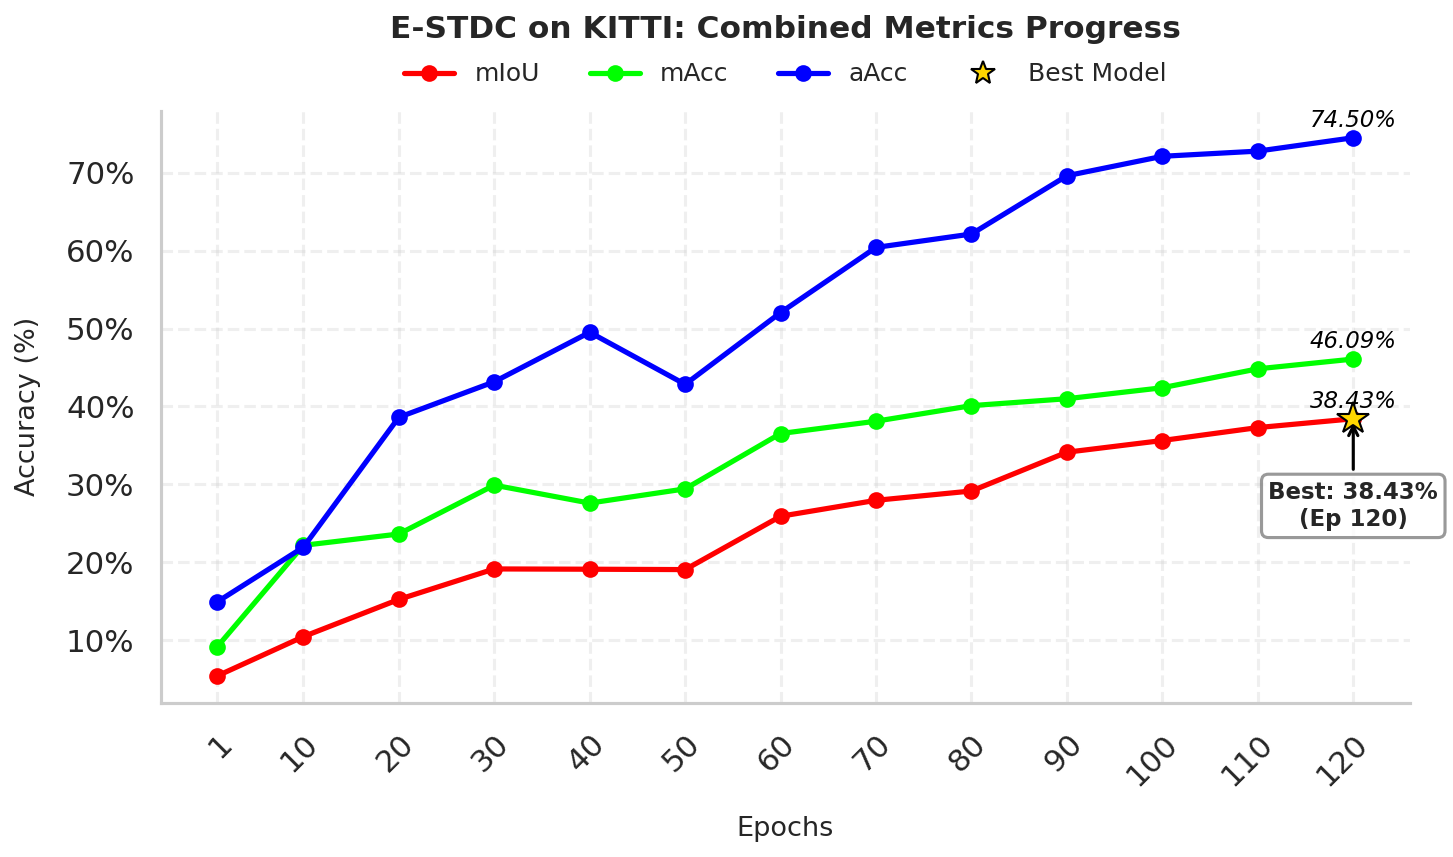

[*] Filtered PolyLR Graph saved successfully to: /home/hrusikesh-nishank/Pictures/E-stdc_kitti/Results_Export_E-stdc_kitti/presentation_learning_rate_schedule_estdc_kitti.png


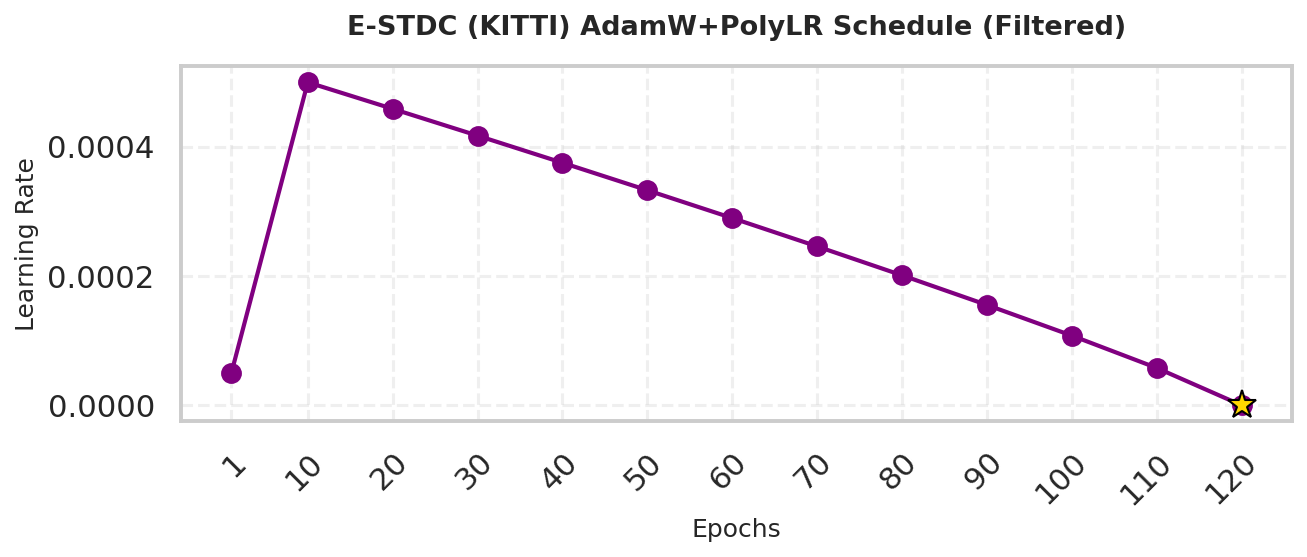

In [9]:
# ============================================================
# STEP 7: FILTERED COMBINED METRICS PLOT & LEARNING RATE
# Target Architecture: E-STDC (STDC Base + EPNet Postprocessing) 
# Target Dataset: KITTI 
# Optimized for: Clean X-Axis, Fixed Legend Overlap
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ---------------------------------------------------------------------
# 0) Safety checks
# ---------------------------------------------------------------------
assert "val_miou" in history and len(history["val_miou"]) > 0, "history['val_miou'] is empty."
assert FINAL_SAVE_DIR.exists(), "FINAL_SAVE_DIR does not exist. Run Step 6 directory setup first."

# ---------------------------------------------------------------------
# 1) Setup Plotting Data vs Axis Ticks
# ---------------------------------------------------------------------
best_miou_raw = max(history["val_miou"])
best_miou_idx = history["val_miou"].index(best_miou_raw)
best_epoch = history["epoch"][best_miou_idx]

# Values are already 0-100 scaled from Step 5.
best_miou_pct = best_miou_raw 

all_epochs = list(range(1, len(history["val_miou"]) + 1))
step = 20 if len(all_epochs) > 150 else 10

# List A: STRICTLY for the X-Axis labels (Clean sequence)
tick_epochs = [e for e in all_epochs if (e == 1) or (e % step == 0)]
if all_epochs[-1] not in tick_epochs:
    tick_epochs.append(all_epochs[-1])
tick_epochs = sorted(list(set(tick_epochs)))

# List B: For plotting the actual lines (Includes the peak epoch to connect the dot)
plot_epochs = tick_epochs.copy()
if best_epoch not in plot_epochs:
    plot_epochs.append(best_epoch)
plot_epochs = sorted(list(set(plot_epochs)))

# Extract metrics using the plot_epochs so the data aligns mathematically
indices = [e - 1 for e in plot_epochs]

miou_scores = [history["val_miou"][i] for i in indices]
macc_scores = [history["val_macc"][i] for i in indices]  
aacc_scores = [history["val_aacc"][i] for i in indices]  

# ---------------------------------------------------------------------
# 2) Plot combined metrics
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6)) # Slightly widened for a cleaner look

ax.plot(plot_epochs, miou_scores, marker="o", color='red', linewidth=2.5, label="mIoU", markersize=7)
ax.plot(plot_epochs, macc_scores, marker="o", color='lime', linewidth=2.5, label="mAcc", markersize=7)
ax.plot(plot_epochs, aacc_scores, marker="o", color='blue', linewidth=2.5, label="aAcc", markersize=7)

# Highlight the Best mIoU Point
ax.plot(best_epoch, best_miou_pct, marker="*", color="gold", markersize=16, markeredgecolor="black", zorder=5)

ax.annotate(
    f"Best: {best_miou_pct:.2f}%\n(Ep {best_epoch})", 
    xy=(best_epoch, best_miou_pct), 
    xytext=(best_epoch, best_miou_pct - 8.0), 
    ha="center", va="top", 
    fontsize=11, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5, connectionstyle="arc3")
)

ax.set_xlabel("Epochs", fontsize=13, labelpad=12)
ax.set_ylabel("Accuracy (%)", fontsize=13, labelpad=12)

# UPDATED: Title to explicitly reflect KITTI
ax.set_title("E-STDC on KITTI: Combined Metrics Progress", fontsize=15, fontweight='bold', pad=35)

# Apply the tick_epochs to keep the axis beautifully clean
ax.set_xticks(tick_epochs)
ax.set_xticklabels([str(e) for e in tick_epochs]) 
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Add percentage values to the final dots
final_x = plot_epochs[-1]
offset = 0.8

ax.text(final_x, miou_scores[-1] + offset, f"{miou_scores[-1]:.2f}%",
        ha="center", va="bottom", fontsize=11, fontstyle="italic", color="black")
ax.text(final_x, macc_scores[-1] + offset, f"{macc_scores[-1]:.2f}%",
        ha="center", va="bottom", fontsize=11, fontstyle="italic", color="black")
ax.text(final_x, aacc_scores[-1] + offset, f"{aacc_scores[-1]:.2f}%",
        ha="center", va="bottom", fontsize=11, fontstyle="italic", color="black")

import matplotlib.lines as mlines
star_legend = mlines.Line2D([], [], color='white', marker='*', markerfacecolor='gold', markeredgecolor='black', markersize=12, label='Best Model')
handles, labels = ax.get_legend_handles_labels()
handles.append(star_legend)

# Adjusted bbox_to_anchor to push the legend cleanly above the plot but below the title
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False, fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()

# UPDATED: Filename safely tags KITTI
combined_graph_path = FINAL_SAVE_DIR / "presentation_combined_metrics_progress_estdc_kitti.png"
plt.savefig(combined_graph_path, dpi=600, bbox_inches="tight")
print(f"[*] Filtered Multi-Metric Graph saved successfully to: {combined_graph_path}")
plt.show()
plt.close()

# ---------------------------------------------------------------------
# 3) Filtered LR plot at the same epochs 
# ---------------------------------------------------------------------
if "learning_rate" in history and len(history["learning_rate"]) > 0:
    lr_points = [history["learning_rate"][i] for i in indices]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(plot_epochs, lr_points, marker="o", linewidth=2.0, color='purple')
    
    best_lr = history["learning_rate"][best_miou_idx]
    ax.plot(best_epoch, best_lr, marker="*", color="gold", markersize=14, markeredgecolor="black", zorder=5)
    
    ax.set_xlabel("Epochs", fontsize=12)
    ax.set_ylabel("Learning Rate", fontsize=12)
    
    ax.set_xticks(tick_epochs)
    ax.set_xticklabels([str(e) for e in tick_epochs]) 
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    ax.grid(True, linestyle="--", alpha=0.3)
    
    # UPDATED: Title explicitly tags KITTI and our AdamW + PolyLR warmup schedule
    ax.set_title("E-STDC (KITTI) AdamW+PolyLR Schedule (Filtered)", fontsize=13, fontweight='bold', pad=15)

    plt.tight_layout()
    
    # UPDATED: Filename safely tags KITTI
    lr_filtered_path = FINAL_SAVE_DIR / "presentation_learning_rate_schedule_estdc_kitti.png"
    plt.savefig(lr_filtered_path, dpi=600, bbox_inches="tight")
    print(f"[*] Filtered PolyLR Graph saved successfully to: {lr_filtered_path}")
    plt.show()
    plt.close()
else:
    print("[!] Learning rate history not found, skipping filtered LR plot.")